<a href="https://colab.research.google.com/github/batgirlsupimpa/UFSC/blob/main/TCC_BIBI_final_17_08_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# INOVAÇÃO, COMPLEXIDADE ECONÔMICA E INSERÇÃO NAS CGV
#
# BLOCO 1
# CONFIGURAÇÃO + LEITURA E LIMPEZA DAS BASES
# ======================================================================

!pip -q install linearmodels openpyxl

# ======================================================================
# 1. BIBLIOTECAS
# ======================================================================

import os
import warnings
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from linearmodels.panel import PanelOLS

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


# ======================================================================
# 2. GOOGLE DRIVE
# ======================================================================

from google.colab import drive

drive.mount("/content/drive")


PASTA = (
    "/content/drive/MyDrive/"
    "DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca"
)


if not os.path.exists(PASTA):
    raise FileNotFoundError(
        f"Pasta não encontrada:\n{PASTA}"
    )


print("\n" + "=" * 80)
print("PASTA DO TCC")
print("=" * 80)

print(PASTA)

print("\nArquivos encontrados:")

for arquivo in os.listdir(PASTA):
    print("•", arquivo)


# ======================================================================
# 3. FUNÇÃO AUXILIAR
# ======================================================================

def conferir_base(nome, df):

    print("\n" + "=" * 80)
    print(nome)
    print("=" * 80)

    print("Shape:", df.shape)

    if "country" in df.columns:
        print(
            "Países:",
            df["country"].dropna().unique()
        )

    if "year" in df.columns and len(df) > 0:
        print(
            "Período:",
            df["year"].min(),
            "-",
            df["year"].max()
        )

    print("\nMissing:")
    print(
        df.isna()
        .sum()
        .sort_values(ascending=False)
    )

    print("\nPrimeiras linhas:")

    display(
        df.head()
    )


# ======================================================================
# 4. OECD TiVA
# ======================================================================

CAMINHO_TIVA = (
    f"{PASTA}/EXGR_DVASH.csv"
)

tiva_raw = pd.read_csv(
    CAMINHO_TIVA,
    sep=",",
    engine="python"
)


print("\n" + "=" * 80)
print("TiVA — ARQUIVO ORIGINAL")
print("=" * 80)

print(
    "Shape original:",
    tiva_raw.shape
)

print(
    "Colunas:",
    tiva_raw.columns.tolist()
)

display(
    tiva_raw.head()
)


# ----------------------------------------------------------------------
# Conferir a unidade da variável
# ----------------------------------------------------------------------

if "UNIT_MEASURE" in tiva_raw.columns:

    print(
        "\nUNIT_MEASURE encontrados:"
    )

    print(
        tiva_raw["UNIT_MEASURE"]
        .dropna()
        .unique()
    )


if "MEASURE" in tiva_raw.columns:

    print(
        "\nMEASURE encontrados:"
    )

    print(
        tiva_raw["MEASURE"]
        .dropna()
        .unique()
    )


# ----------------------------------------------------------------------
# Filtrar China e Índia
# ----------------------------------------------------------------------

tiva = tiva_raw[
    tiva_raw["REF_AREA"].isin(
        ["CHN", "IND"]
    )
].copy()


# ----------------------------------------------------------------------
# Manter a medida percentual nas exportações brutas
# ----------------------------------------------------------------------

if "UNIT_MEASURE" in tiva.columns:

    if "PT_EXGR" in tiva["UNIT_MEASURE"].dropna().unique():

        tiva = tiva[
            tiva["UNIT_MEASURE"] == "PT_EXGR"
        ].copy()


# ----------------------------------------------------------------------
# Renomear corretamente
# ----------------------------------------------------------------------

tiva = tiva.rename(
    columns={
        "REF_AREA": "country",
        "TIME_PERIOD": "year",
        "ACTIVITY": "sector",
        "OBS_VALUE": "DVA_SHARE"
    }
)


tiva = tiva[
    [
        "country",
        "year",
        "sector",
        "DVA_SHARE"
    ]
].copy()


# ----------------------------------------------------------------------
# Tipos
# ----------------------------------------------------------------------

tiva["year"] = pd.to_numeric(
    tiva["year"],
    errors="coerce"
)

tiva["DVA_SHARE"] = pd.to_numeric(
    tiva["DVA_SHARE"],
    errors="coerce"
)


tiva = tiva.dropna(
    subset=[
        "country",
        "year",
        "sector",
        "DVA_SHARE"
    ]
)


tiva["year"] = tiva["year"].astype(int)


# ----------------------------------------------------------------------
# Período do TCC
# ----------------------------------------------------------------------

tiva = tiva[
    tiva["year"].between(
        1995,
        2022
    )
].copy()


tiva = (
    tiva
    .sort_values(
        [
            "country",
            "sector",
            "year"
        ]
    )
    .reset_index(drop=True)
)


conferir_base(
    "TiVA TRATADA",
    tiva
)


print(
    "\nSetores TiVA:",
    tiva["sector"].nunique()
)


# ======================================================================
# 5. PENN WORLD TABLE 11.0
# ======================================================================

CAMINHO_PWT = (
    f"{PASTA}/pwt110.xlsx"
)


pwt_raw = pd.read_excel(
    CAMINHO_PWT,
    sheet_name="Data"
)


print("\n" + "=" * 80)
print("PWT — ARQUIVO ORIGINAL")
print("=" * 80)

print(
    "Shape original:",
    pwt_raw.shape
)


# ----------------------------------------------------------------------
# Variáveis utilizadas
# ----------------------------------------------------------------------

pwt = pwt_raw[
    [
        "countrycode",
        "year",
        "ctfp",
        "hc",
        "rgdpe",
        "pop",
        "emp"
    ]
].copy()


pwt = pwt.rename(
    columns={
        "countrycode": "country",
        "ctfp": "PTF",
        "hc": "HumanCapital",
        "rgdpe": "GDP",
        "pop": "Population",
        "emp": "Employment"
    }
)


# ----------------------------------------------------------------------
# China e Índia
# ----------------------------------------------------------------------

pwt = pwt[
    pwt["country"].isin(
        ["CHN", "IND"]
    )
].copy()


# ----------------------------------------------------------------------
# Tipos
# ----------------------------------------------------------------------

pwt["year"] = pd.to_numeric(
    pwt["year"],
    errors="coerce"
)


for coluna in [
    "PTF",
    "HumanCapital",
    "GDP",
    "Population",
    "Employment"
]:

    pwt[coluna] = pd.to_numeric(
        pwt[coluna],
        errors="coerce"
    )


pwt = pwt.dropna(
    subset=[
        "country",
        "year"
    ]
)


pwt["year"] = pwt["year"].astype(int)


# ----------------------------------------------------------------------
# Período
# ----------------------------------------------------------------------

pwt = pwt[
    pwt["year"].between(
        1995,
        2022
    )
].copy()


pwt = (
    pwt
    .drop_duplicates(
        ["country", "year"]
    )
    .sort_values(
        ["country", "year"]
    )
    .reset_index(drop=True)
)


conferir_base(
    "PWT TRATADA",
    pwt
)


# ======================================================================
# 6. BANCO MUNDIAL — API OFICIAL
# ======================================================================

INDICADORES_WB = {

    # PIB per capita real
    "NY.GDP.PCAP.KD": "PIBpc",

    # Gastos em P&D (% PIB)
    "GB.XPD.RSDV.GD.ZS": "RD"
}


def baixar_world_bank(
    codigo,
    nome_variavel
):

    url = (
        "https://api.worldbank.org/v2/"
        f"country/CHN;IND/indicator/{codigo}"
    )

    parametros = {
        "format": "json",
        "date": "1995:2022",
        "per_page": 2000
    }

    resposta = requests.get(
        url,
        params=parametros,
        timeout=60
    )

    resposta.raise_for_status()

    conteudo = resposta.json()


    if (
        not isinstance(conteudo, list)
        or len(conteudo) < 2
        or conteudo[1] is None
    ):

        raise ValueError(
            f"Banco Mundial não retornou dados para {codigo}"
        )


    registros = []


    for item in conteudo[1]:

        country = item.get(
            "countryiso3code"
        )


        if country not in [
            "CHN",
            "IND"
        ]:

            nome_pais = (
                item
                .get("country", {})
                .get("value")
            )

            mapa = {
                "China": "CHN",
                "India": "IND"
            }

            country = mapa.get(
                nome_pais
            )


        registros.append(
            {
                "country": country,
                "year": int(
                    item["date"]
                ),
                nome_variavel: item["value"]
            }
        )


    resultado = pd.DataFrame(
        registros
    )


    resultado = resultado[
        resultado["country"].isin(
            ["CHN", "IND"]
        )
    ].copy()


    resultado[nome_variavel] = pd.to_numeric(
        resultado[nome_variavel],
        errors="coerce"
    )


    resultado = (
        resultado
        .drop_duplicates(
            ["country", "year"]
        )
        .sort_values(
            ["country", "year"]
        )
        .reset_index(drop=True)
    )


    return resultado


# ----------------------------------------------------------------------
# Baixar indicadores
# ----------------------------------------------------------------------

bases_wb = []


for codigo, nome in INDICADORES_WB.items():

    print(
        f"\nBaixando {nome}..."
    )

    temp = baixar_world_bank(
        codigo,
        nome
    )

    print(
        nome,
        temp.shape
    )

    bases_wb.append(
        temp
    )


# ----------------------------------------------------------------------
# Merge das séries do Banco Mundial
# ----------------------------------------------------------------------

wb = bases_wb[0].copy()


for temp in bases_wb[1:]:

    wb = wb.merge(
        temp,
        on=[
            "country",
            "year"
        ],
        how="outer",
        validate="one_to_one"
    )


wb = (
    wb
    .sort_values(
        ["country", "year"]
    )
    .reset_index(drop=True)
)


conferir_base(
    "BANCO MUNDIAL",
    wb
)


# ----------------------------------------------------------------------
# Garantias
# ----------------------------------------------------------------------

if wb["PIBpc"].notna().sum() == 0:

    raise ValueError(
        "PIBpc veio completamente vazio."
    )


if wb["RD"].notna().sum() == 0:

    raise ValueError(
        "P&D veio completamente vazio."
    )


# ======================================================================
# 7. ECONOMIC COMPLEXITY INDEX — ECI
# ======================================================================

CAMINHO_ECI = (
    f"{PASTA}/growth_proj_eci_rankings.csv"
)


eci_raw = pd.read_csv(
    CAMINHO_ECI
)


print("\n" + "=" * 80)
print("ECI — ARQUIVO ORIGINAL")
print("=" * 80)

print(
    "Shape:",
    eci_raw.shape
)

print(
    "Colunas:",
    eci_raw.columns.tolist()
)


# ----------------------------------------------------------------------
# Preparação
# ----------------------------------------------------------------------

eci = eci_raw.copy()


eci = eci.rename(
    columns={
        "country_iso3_code": "country",
        "eci_sitc": "ECI"
    }
)


colunas_necessarias = [
    "country",
    "year",
    "ECI"
]


faltando = [
    coluna
    for coluna
    in colunas_necessarias
    if coluna not in eci.columns
]


if faltando:

    raise ValueError(
        f"Colunas ausentes no ECI: {faltando}"
    )


eci = eci[
    colunas_necessarias
].copy()


eci = eci[
    eci["country"].isin(
        ["CHN", "IND"]
    )
].copy()


eci["year"] = pd.to_numeric(
    eci["year"],
    errors="coerce"
)


eci["ECI"] = pd.to_numeric(
    eci["ECI"],
    errors="coerce"
)


eci = eci.dropna(
    subset=[
        "country",
        "year",
        "ECI"
    ]
)


eci["year"] = eci[
    "year"
].astype(int)


eci = eci[
    eci["year"].between(
        1995,
        2022
    )
].copy()


eci = (
    eci
    .drop_duplicates(
        ["country", "year"]
    )
    .sort_values(
        ["country", "year"]
    )
    .reset_index(drop=True)
)


conferir_base(
    "ECI TRATADO",
    eci
)


# ======================================================================
# 8. CHECK FINAL DO BLOCO 1
# ======================================================================

print("\n" + "=" * 80)
print("CHECK FINAL — BLOCO 1")
print("=" * 80)

print(
    "TiVA:",
    tiva.shape
)

print(
    "PWT:",
    pwt.shape
)

print(
    "World Bank:",
    wb.shape
)

print(
    "ECI:",
    eci.shape
)


print("\nPaíses:")

print(
    "TiVA:",
    tiva["country"].unique()
)

print(
    "PWT:",
    pwt["country"].unique()
)

print(
    "WB:",
    wb["country"].unique()
)

print(
    "ECI:",
    eci["country"].unique()
)


print("\nTiVA:")

print(
    "Período:",
    tiva["year"].min(),
    "-",
    tiva["year"].max()
)

print(
    "Setores:",
    tiva["sector"].nunique()
)

print(
    "DVA_SHARE mínimo:",
    tiva["DVA_SHARE"].min()
)

print(
    "DVA_SHARE máximo:",
    tiva["DVA_SHARE"].max()
)


print("\n" + "=" * 80)
print("BLOCO 1 CONCLUÍDO")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PASTA DO TCC
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca

Arquivos encontrados:
• OECD.STI.PIE,DSD_TIVA_MAINSH@DF_MAINSH,1.1,filtered,2026-02-17 17-46-17.xlsx
• Gráficos 17.02.2026
• pwt110.xlsx
• growth_proj_eci_rankings.csv
• EXGR_DVASH.csv
• estatisticas_descritivas.xlsx
• painel_final.xlsx
• resultado_FE.txt
• resultado_RE.txt
• tiva_limpa.xlsx
• TCC 2026 - bibi.gdoc
• PAINEL_FINAL_TCC.xlsx
• BASE_ECONOMETRICA_TCC.xlsx
• RESULTADOS_TCC_FINAL.xlsx
• OLS_MODELO_1.txt
• OLS_MODELO_2.txt
• OLS_MODELO_3.txt
• FIXED_EFFECTS.txt
• FIXED_EFFECTS_TIME.txt
• RANDOM_EFFECTS.txt
• HAUSMAN.txt
• DIAGNOSTICOS_OLS.txt
• TABELA_ECONOMETRICA_FINAL.xlsx
• TABELA_ECONOMETRICA_FINAL.csv
• TABELA_FINAL_TCC_DEFINITIVA.xlsx
• grafico_DVA_share.png
• grafico_PTF.png
• grafico_capital_humano.png
• grafico_PIBpc.png
• grafico_RD.png
• grafico_ECI.png
• b

,DATAFLOW,MEASURE,REF_AREA,ACTIVITY,COUNTERPART_AREA,UNIT_MEASURE,FREQ,TIME_PERIOD,OBS_VALUE,UNIT_MULT
0,OECD.STI.PIE:DSD_TIVA_MAINSH@DF_MAINSH(1.1),EXGR_DVA,AGO,A01,W,PT_EXGR,A,1995,77.308,0
1,OECD.STI.PIE:DSD_TIVA_MAINSH@DF_MAINSH(1.1),EXGR_DVA,AGO,A01,W,PT_EXGR,A,1996,75.459,0
2,OECD.STI.PIE:DSD_TIVA_MAINSH@DF_MAINSH(1.1),EXGR_DVA,AGO,A01,W,PT_EXGR,A,1997,82.034,0
3,OECD.STI.PIE:DSD_TIVA_MAINSH@DF_MAINSH(1.1),EXGR_DVA,AGO,A01,W,PT_EXGR,A,1998,82.938,0
4,OECD.STI.PIE:DSD_TIVA_MAINSH@DF_MAINSH(1.1),EXGR_DVA,AGO,A01,W,PT_EXGR,A,1999,63.725,0



UNIT_MEASURE encontrados:
['PT_EXGR']

MEASURE encontrados:
['EXGR_DVA']

TiVA TRATADA
Shape: (4424, 4)
Países: ['CHN' 'IND']
Período: 1995 - 2022

Missing:
country      0
year         0
sector       0
DVA_SHARE    0
dtype: int64

Primeiras linhas:


,country,year,sector,DVA_SHARE
0,CHN,1995,A,98.251
1,CHN,1996,A,98.400
2,CHN,1997,A,97.366
3,CHN,1998,A,98.079
4,CHN,1999,A,97.401



Setores TiVA: 79

PWT — ARQUIVO ORIGINAL
Shape original: (13690, 51)

PWT TRATADA
Shape: (56, 7)
Países: ['CHN' 'IND']
Período: 1995 - 2022

Missing:
country         0
year            0
PTF             0
HumanCapital    0
GDP             0
Population      0
Employment      0
dtype: int64

Primeiras linhas:


...


Baixando PIBpc...
PIBpc (56, 3)

Baixando RD...
RD (56, 3)

BANCO MUNDIAL
Shape: (56, 4)
Países: ['CHN' 'IND']
Período: 1995 - 2022

Missing:
RD         4
country    0
year       0
PIBpc      0
dtype: int64

Primeiras linhas:


,country,year,PIBpc,RD
0,CHN,1995,1545.078978,NaN
1,CHN,1996,1681.457413,0.56014
2,CHN,1997,1819.079541,0.63467
3,CHN,1998,1944.467186,0.64185
4,CHN,1999,2076.931803,0.74295



ECI — ARQUIVO ORIGINAL
Shape: (4319, 11)
Colunas: ['country_id', 'country_iso3_code', 'year', 'growth_proj', 'in_rankings', 'eci_sitc', 'eci_rank_sitc', 'eci_hs92', 'eci_rank_hs92', 'eci_hs12', 'eci_rank_hs12']

ECI TRATADO
Shape: (56, 3)
Países: ['CHN' 'IND']
Período: 1995 - 2022

Missing:
country    0
year       0
ECI        0
dtype: int64

Primeiras linhas:


,country,year,ECI
0,CHN,1995,0.716
1,CHN,1996,0.689
2,CHN,1997,0.689
3,CHN,1998,0.712
4,CHN,1999,0.740



CHECK FINAL — BLOCO 1
TiVA: (4424, 4)
PWT: (56, 7)
World Bank: (56, 4)
ECI: (56, 3)

Países:
TiVA: ['CHN' 'IND']
PWT: ['CHN' 'IND']
WB: ['CHN' 'IND']
ECI: ['CHN' 'IND']

TiVA:
Período: 1995 - 2022
Setores: 79
DVA_SHARE mínimo: 29.169
DVA_SHARE máximo: 99.687

BLOCO 1 CONCLUÍDO


In [47]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# BLOCO 2
# MERGE DAS BASES + CONSTRUÇÃO DA BASE FINAL
# ======================================================================


# ======================================================================
# 1. CONFERÊNCIA ANTES DOS MERGES
# ======================================================================

print("=" * 80)
print("CONFERÊNCIA DAS BASES ANTES DOS MERGES")
print("=" * 80)

print("TiVA:", tiva.shape)
print("PWT :", pwt.shape)
print("WB  :", wb.shape)
print("ECI :", eci.shape)

print("\nPaíses em cada base:")

print("TiVA:", tiva["country"].unique())
print("PWT :", pwt["country"].unique())
print("WB  :", wb["country"].unique())
print("ECI :", eci["country"].unique())

print("\nPeríodos:")

print(
    "TiVA:",
    tiva["year"].min(),
    "-",
    tiva["year"].max()
)

print(
    "PWT:",
    pwt["year"].min(),
    "-",
    pwt["year"].max()
)

print(
    "WB:",
    wb["year"].min(),
    "-",
    wb["year"].max()
)

print(
    "ECI:",
    eci["year"].min(),
    "-",
    eci["year"].max()
)


# ======================================================================
# 2. MERGE TiVA + PWT
# ======================================================================

panel = tiva.merge(
    pwt,
    on=[
        "country",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

print("\nApós merge TiVA + PWT:")
print(panel.shape)

if len(panel) != len(tiva):

    raise ValueError(
        "O merge com a PWT alterou o número de linhas da TiVA."
    )


# ======================================================================
# 3. MERGE COM BANCO MUNDIAL
# ======================================================================

panel = panel.merge(
    wb,
    on=[
        "country",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

print("\nApós merge com Banco Mundial:")
print(panel.shape)

if len(panel) != len(tiva):

    raise ValueError(
        "O merge com o Banco Mundial alterou o número de linhas."
    )


# ======================================================================
# 4. MERGE COM ECI
# ======================================================================

panel = panel.merge(
    eci,
    on=[
        "country",
        "year"
    ],
    how="left",
    validate="many_to_one"
)

print("\nApós merge com ECI:")
print(panel.shape)

if len(panel) != len(tiva):

    raise ValueError(
        "O merge com o ECI alterou o número de linhas."
    )


# ======================================================================
# 5. CRIAÇÃO DAS VARIÁVEIS TRANSFORMADAS
# ======================================================================

panel = panel.copy()


# ----------------------------------------------------------------------
# Dependente
# participação do valor adicionado doméstico nas exportações brutas
# ----------------------------------------------------------------------

panel["ln_DVA_SHARE"] = np.where(
    panel["DVA_SHARE"] > 0,
    np.log(
        panel["DVA_SHARE"]
    ),
    np.nan
)


# ----------------------------------------------------------------------
# PIB per capita em log
# ----------------------------------------------------------------------

panel["ln_PIBpc"] = np.where(
    panel["PIBpc"] > 0,
    np.log(
        panel["PIBpc"]
    ),
    np.nan
)


# ----------------------------------------------------------------------
# Outras transformações úteis para descritivas
# ----------------------------------------------------------------------

panel["ln_GDP"] = np.where(
    panel["GDP"] > 0,
    np.log(
        panel["GDP"]
    ),
    np.nan
)

panel["ln_Population"] = np.where(
    panel["Population"] > 0,
    np.log(
        panel["Population"]
    ),
    np.nan
)

panel["ln_Employment"] = np.where(
    panel["Employment"] > 0,
    np.log(
        panel["Employment"]
    ),
    np.nan
)


# ======================================================================
# 6. CRIAR ENTIDADE DO PAINEL
# PAÍS × SETOR
# ======================================================================

panel["entity"] = (
    panel["country"].astype(str)
    + "_"
    + panel["sector"].astype(str)
)


print(
    "\nNúmero de entidades país-setor:",
    panel["entity"].nunique()
)


# ======================================================================
# 7. ORDENAR BASE
# ======================================================================

panel = (
    panel
    .sort_values(
        [
            "country",
            "sector",
            "year"
        ]
    )
    .reset_index(drop=True)
)


# ======================================================================
# 8. CONFERÊNCIA DA BASE COMPLETA
# ======================================================================

print("\n" + "=" * 80)
print("BASE COMPLETA APÓS OS MERGES")
print("=" * 80)

print(
    "Shape:",
    panel.shape
)

print(
    "Países:",
    panel["country"].unique()
)

print(
    "Período:",
    panel["year"].min(),
    "-",
    panel["year"].max()
)

print(
    "Setores:",
    panel["sector"].nunique()
)

print(
    "Entidades país-setor:",
    panel["entity"].nunique()
)


print("\nMissing por variável:")

print(
    panel.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

display(
    panel.head(10)
)


# ======================================================================
# 9. CHECAR DUPLICATAS ENTIDADE-ANO
# ======================================================================

duplicadas = panel.duplicated(
    [
        "entity",
        "year"
    ]
).sum()


print(
    "\nDuplicatas entity-year:",
    duplicadas
)


if duplicadas > 0:

    print(
        "\nATENÇÃO: foram encontradas duplicatas."
    )

    display(
        panel[
            panel.duplicated(
                [
                    "entity",
                    "year"
                ],
                keep=False
            )
        ]
        .sort_values(
            [
                "entity",
                "year"
            ]
        )
        .head(30)
    )

    raise ValueError(
        "Existem duplicatas entity-year. "
        "A base não deve seguir para a econometria."
    )

else:

    print(
        "Nenhuma duplicata entity-year."
    )


# ======================================================================
# 10. COBERTURA DAS VARIÁVEIS DO MODELO
# ======================================================================

variaveis_modelo = [
    "ln_DVA_SHARE",
    "PTF",
    "HumanCapital",
    "ln_PIBpc",
    "RD",
    "ECI"
]


print("\n" + "=" * 80)
print("COBERTURA DAS VARIÁVEIS DO MODELO")
print("=" * 80)


for variavel in variaveis_modelo:

    total = len(panel)

    validos = (
        panel[variavel]
        .notna()
        .sum()
    )

    percentual = (
        validos
        / total
        * 100
    )

    print(
        f"{variavel:20s} "
        f"{validos:6d} "
        f"({percentual:6.2f}%)"
    )


# ======================================================================
# 11. CONSTRUIR AMOSTRA ECONOMÉTRICA FINAL
# ======================================================================

base_final = (
    panel
    .dropna(
        subset=variaveis_modelo
    )
    .copy()
)


print("\n" + "=" * 80)
print("AMOSTRA ECONOMÉTRICA FINAL")
print("=" * 80)

print(
    "Shape:",
    base_final.shape
)

print(
    "Observações:",
    len(base_final)
)

print(
    "Países:",
    base_final["country"].unique()
)

print(
    "Período:",
    base_final["year"].min(),
    "-",
    base_final["year"].max()
)

print(
    "Setores:",
    base_final["sector"].nunique()
)

print(
    "Entidades país-setor:",
    base_final["entity"].nunique()
)


# ======================================================================
# 12. MISSING NA AMOSTRA FINAL
# ======================================================================

print("\nMissing nas variáveis do modelo:")

print(
    base_final[
        variaveis_modelo
    ]
    .isna()
    .sum()
)


# ======================================================================
# 13. CHECAR QUANTOS ANOS EXISTEM POR ENTIDADE
# ======================================================================

anos_por_entidade = (
    base_final
    .groupby("entity")["year"]
    .nunique()
)


print("\n" + "=" * 80)
print("ANOS POR ENTIDADE")
print("=" * 80)

print(
    "Mínimo:",
    anos_por_entidade.min()
)

print(
    "Média:",
    round(
        anos_por_entidade.mean(),
        2
    )
)

print(
    "Máximo:",
    anos_por_entidade.max()
)


# ======================================================================
# 14. CONFERIR A VARIÁVEL DEPENDENTE
# ======================================================================

print("\n" + "=" * 80)
print("VARIÁVEL DEPENDENTE")
print("=" * 80)

print(
    "DVA_SHARE mínimo:",
    base_final["DVA_SHARE"].min()
)

print(
    "DVA_SHARE médio:",
    base_final["DVA_SHARE"].mean()
)

print(
    "DVA_SHARE máximo:",
    base_final["DVA_SHARE"].max()
)

print()

print(
    "ln_DVA_SHARE mínimo:",
    base_final["ln_DVA_SHARE"].min()
)

print(
    "ln_DVA_SHARE médio:",
    base_final["ln_DVA_SHARE"].mean()
)

print(
    "ln_DVA_SHARE máximo:",
    base_final["ln_DVA_SHARE"].max()
)


# ======================================================================
# 15. CHECK FINAL DO BLOCO 2
# ======================================================================

print("\n" + "=" * 80)
print("CHECK FINAL — BLOCO 2")
print("=" * 80)

print(
    "Painel completo:",
    len(panel),
    "observações"
)

print(
    "Amostra econométrica:",
    len(base_final),
    "observações"
)

print(
    "Países:",
    base_final["country"].nunique()
)

print(
    "Setores:",
    base_final["sector"].nunique()
)

print(
    "Entidades país-setor:",
    base_final["entity"].nunique()
)

print(
    "Período:",
    base_final["year"].min(),
    "-",
    base_final["year"].max()
)

print(
    "Duplicatas entity-year:",
    base_final.duplicated(
        [
            "entity",
            "year"
        ]
    ).sum()
)

print("\n" + "=" * 80)
print("BLOCO 2 CONCLUÍDO")
print("=" * 80)

CONFERÊNCIA DAS BASES ANTES DOS MERGES
TiVA: (4424, 4)
PWT : (56, 7)
WB  : (56, 4)
ECI : (56, 3)

Países em cada base:
TiVA: ['CHN' 'IND']
PWT : ['CHN' 'IND']
WB  : ['CHN' 'IND']
ECI : ['CHN' 'IND']

Períodos:
TiVA: 1995 - 2022
PWT: 1995 - 2022
WB: 1995 - 2022
ECI: 1995 - 2022

Após merge TiVA + PWT:
(4424, 9)

Após merge com Banco Mundial:
(4424, 11)

Após merge com ECI:
(4424, 12)

Número de entidades país-setor: 158

BASE COMPLETA APÓS OS MERGES
Shape: (4424, 18)
Países: ['CHN' 'IND']
Período: 1995 - 2022
Setores: 79
Entidades país-setor: 158

Missing por variável:
RD               316
country            0
year               0
sector             0
PTF                0
DVA_SHARE          0
GDP                0
Population         0
Employment         0
HumanCapital       0
PIBpc              0
ECI                0
ln_DVA_SHARE       0
ln_PIBpc           0
ln_GDP             0
ln_Population      0
ln_Employment      0
entity             0
dtype: int64


,country,year,sector,DVA_SHARE,PTF,HumanCapital,GDP,Population,Employment,PIBpc,RD,ECI,ln_DVA_SHARE,ln_PIBpc,ln_GDP,ln_Population,ln_Employment,entity
0,CHN,1995,A,98.251,0.315399,2.138094,3900627.5,1220.133927,687.490051,1545.078978,NaN,0.716,4.587525,7.342830,15.176648,7.106716,6.533047,CHN_A
1,CHN,1996,A,98.400,0.313980,2.172085,4297152.5,1230.944812,693.967651,1681.457413,0.56014,0.689,4.589041,7.427416,15.273463,7.115537,6.542425,CHN_A
2,CHN,1997,A,97.366,0.313750,2.206615,4669251.0,1241.139622,701.586731,1819.079541,0.63467,0.689,4.578477,7.506086,15.356509,7.123785,6.553345,CHN_A
3,CHN,1998,A,98.079,0.308849,2.241695,5063926.0,1250.847127,709.159180,1944.467186,0.64185,0.712,4.585773,7.572743,15.437653,7.131576,6.564080,CHN_A
4,CHN,1999,A,97.401,0.310680,2.277333,5489099.0,1260.176655,716.567688,2076.931803,0.74295,0.740,4.578836,7.638647,15.518275,7.139007,6.574473,CHN_A
5,CHN,2000,A,95.016,0.326037,2.313537,5985309.5,1269.581175,723.768677,2237.300479,0.88409,0.872,4.554045,7.713025,15.604819,7.146442,6.584472,CHN_A
6,CHN,2001,A,96.224,0.338365,2.329684,6520996.5,1278.725063,731.011230,2405.994119,0.92948,0.880,4.566679,7.785718,15.690538,7.153619,6.594429,CHN_A
7,CHN,2002,A,94.838,0.342091,2.345942,7119989.0,1286.866839,736.963867,2610.662751,1.04418,0.898,4.552170,7.867359,15.778417,7.159966,6.602539,CHN_A
8,CHN,2003,A,95.166,0.350558,2.362315,7792220.0,1294.517326,741.641785,2856.850533,1.10465,0.974,4.555623,7.957475,15.868636,7.165893,6.608866,CHN_A
9,CHN,2004,A,95.111,0.368637,2.378802,8640414.0,1302.100316,746.582581,3127.914449,1.19732,1.012,4.555045,8.048122,15.971961,7.171734,6.615506,CHN_A



Duplicatas entity-year: 0
Nenhuma duplicata entity-year.

COBERTURA DAS VARIÁVEIS DO MODELO
ln_DVA_SHARE           4424 (100.00%)
PTF                    4424 (100.00%)
HumanCapital           4424 (100.00%)
ln_PIBpc               4424 (100.00%)
RD                     4108 ( 92.86%)
ECI                    4424 (100.00%)

AMOSTRA ECONOMÉTRICA FINAL
Shape: (4108, 18)
Observações: 4108
Países: ['CHN' 'IND']
Período: 1996 - 2022
Setores: 79
Entidades país-setor: 158

Missing nas variáveis do modelo:
ln_DVA_SHARE    0
PTF             0
HumanCapital    0
ln_PIBpc        0
RD              0
ECI             0
dtype: int64

ANOS POR ENTIDADE
Mínimo: 25
Média: 26.0
Máximo: 27

VARIÁVEL DEPENDENTE
DVA_SHARE mínimo: 29.169
DVA_SHARE médio: 85.16780379746835
DVA_SHARE máximo: 99.663

ln_DVA_SHARE mínimo: 3.37310650149563
ln_DVA_SHARE médio: 4.436878377813577
ln_DVA_SHARE máximo: 4.601794494748175

CHECK FINAL — BLOCO 2
Painel completo: 4424 observações
Amostra econométrica: 4108 observações
Países: 

ESTATÍSTICAS DESCRITIVAS — AMOSTRA ECONOMÉTRICA


,count,mean,std,min,25%,50%,75%,max
DVA nas exportações (%),4108.0,85.168,9.857,29.169,80.186,87.411,92.176,99.663
Produtividade Total dos Fatores,4108.0,0.374,0.048,0.302,0.324,0.382,0.406,0.474
Capital Humano,4108.0,2.210,0.315,1.640,1.938,2.201,2.434,2.741
PIB per capita,4108.0,3573.770,3294.563,654.356,1137.953,1909.694,5369.504,11830.299
P&D (% do PIB),4108.0,1.154,0.586,0.560,0.706,0.815,1.649,2.494
Complexidade Econômica,4108.0,0.809,0.394,0.298,0.440,0.689,1.196,1.488



MÉDIAS POR PAÍS


,DVA nas exportações (%),PTF,Capital Humano,PIB per capita,P&D (% PIB),ECI
País,,,,,,
China,86.918,0.391,2.470,5789.631,1.546,1.140
Índia,83.277,0.357,1.929,1180.640,0.731,0.451



BASE ANUAL PARA OS GRÁFICOS
Observações: 52
Período: 1996 - 2022


,country,País,year,DVA_SHARE,PTF,HumanCapital,PIBpc,RD,ECI
0,CHN,China,1996,89.234506,0.313980,2.172085,1681.457413,0.56014,0.689
1,CHN,China,1997,89.382089,0.313750,2.206615,1819.079541,0.63467,0.689
2,CHN,China,1998,89.784810,0.308849,2.241695,1944.467186,0.64185,0.712
3,CHN,China,1999,88.654076,0.310680,2.277333,2076.931803,0.74295,0.740
4,CHN,China,2000,87.369494,0.326037,2.313537,2237.300479,0.88409,0.872


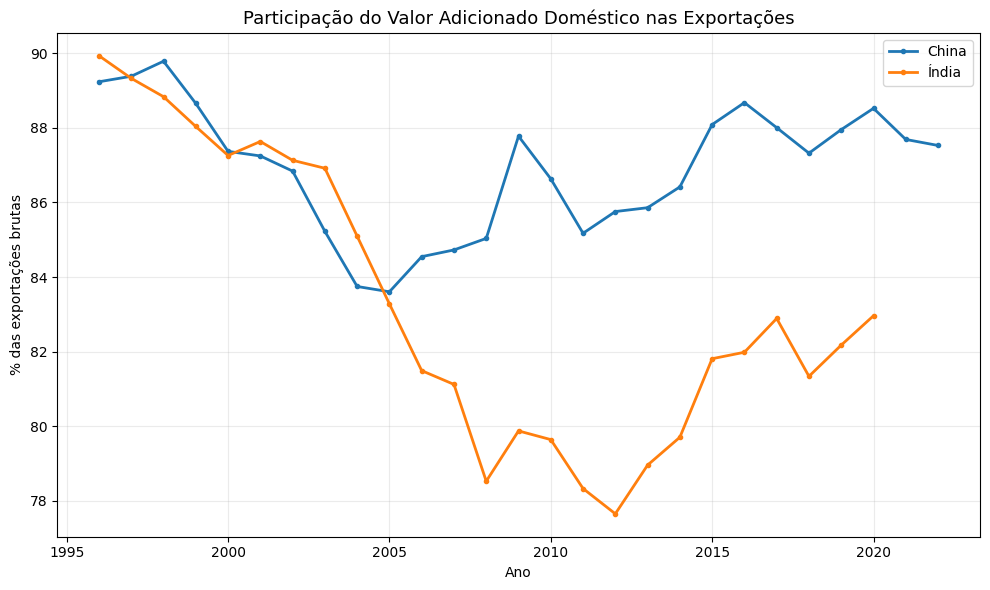

Gráfico salvo em: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/grafico_DVA_share.png


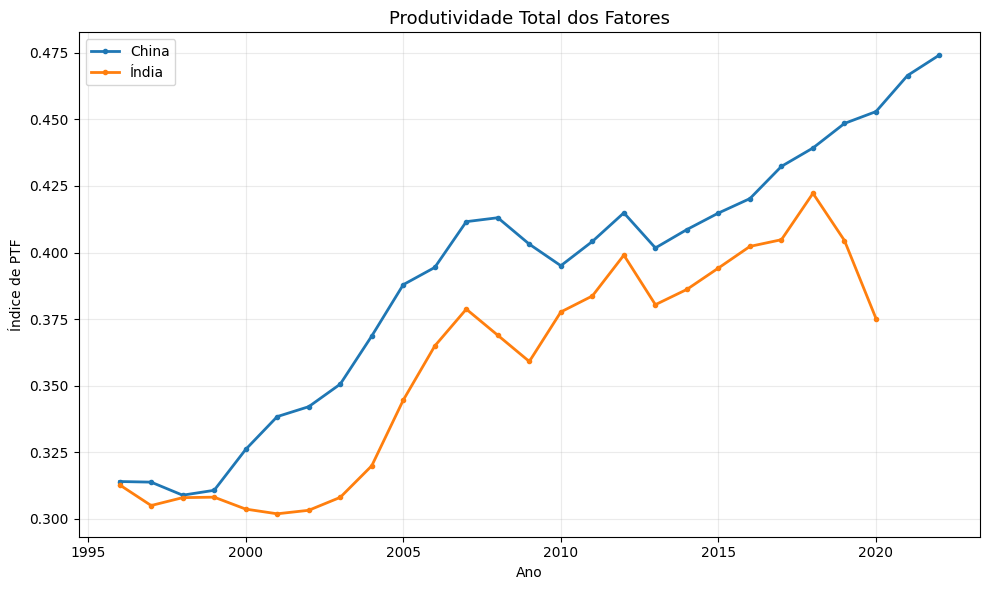

Gráfico salvo em: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/grafico_PTF.png


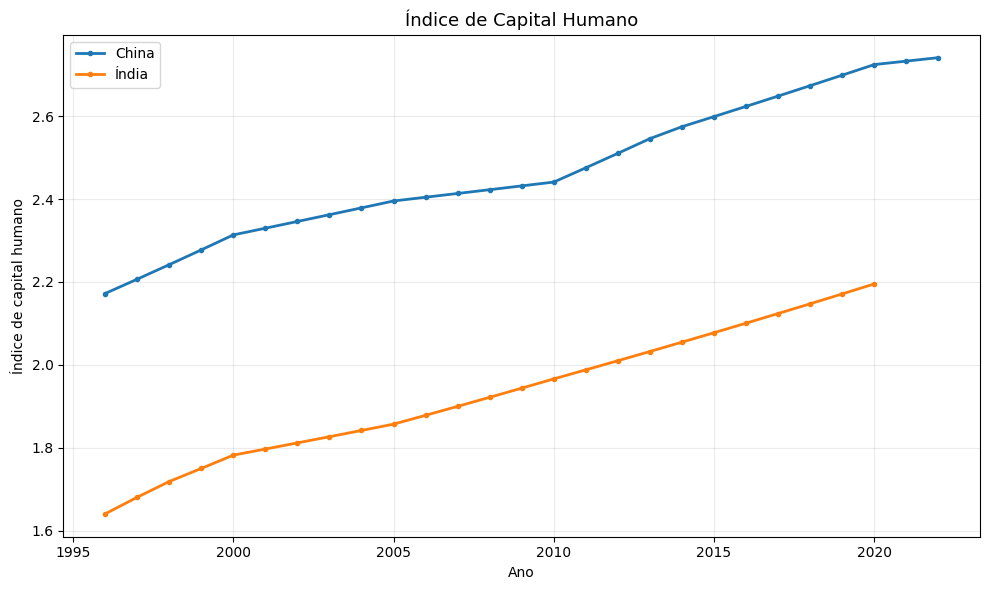

Gráfico salvo em: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/grafico_capital_humano.png


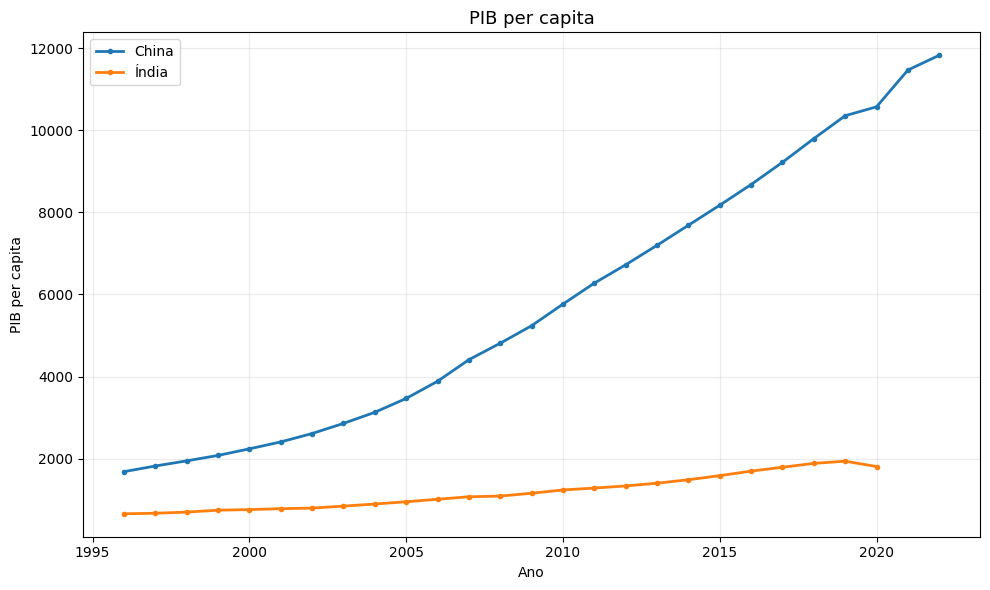

Gráfico salvo em: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/grafico_PIBpc.png


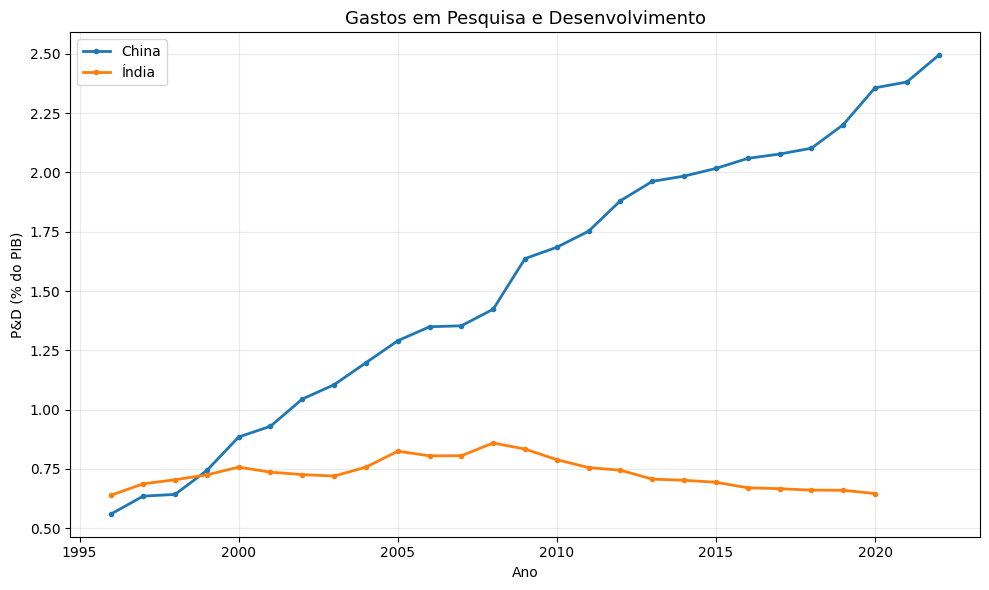

Gráfico salvo em: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/grafico_RD.png


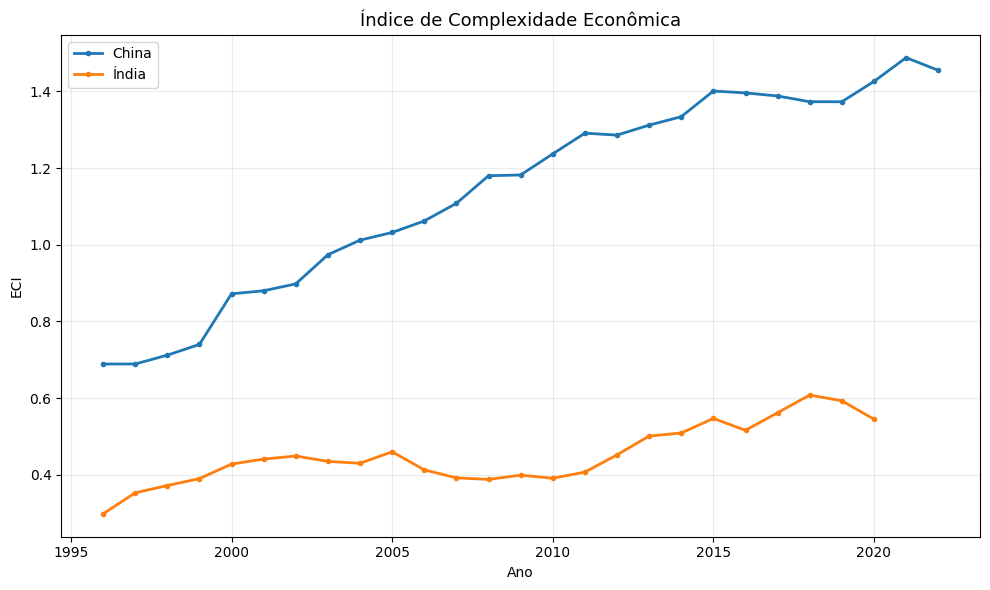

Gráfico salvo em: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/grafico_ECI.png


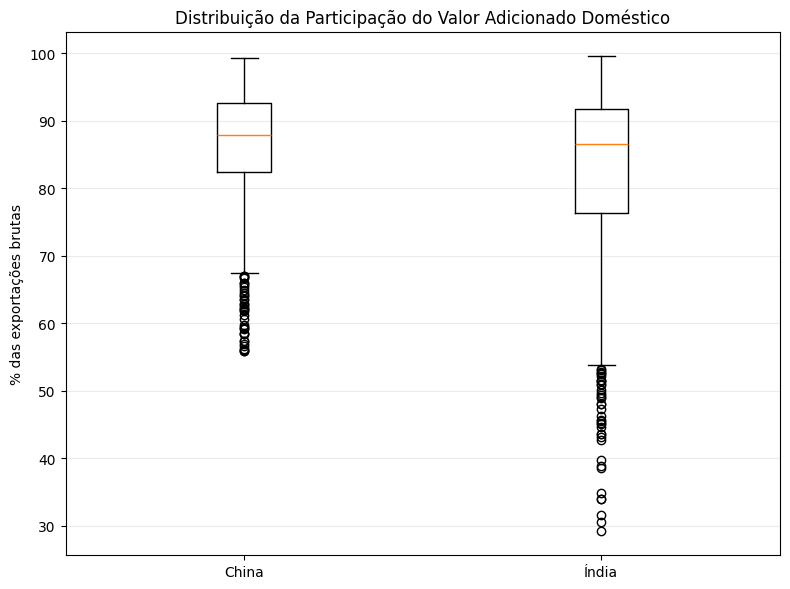

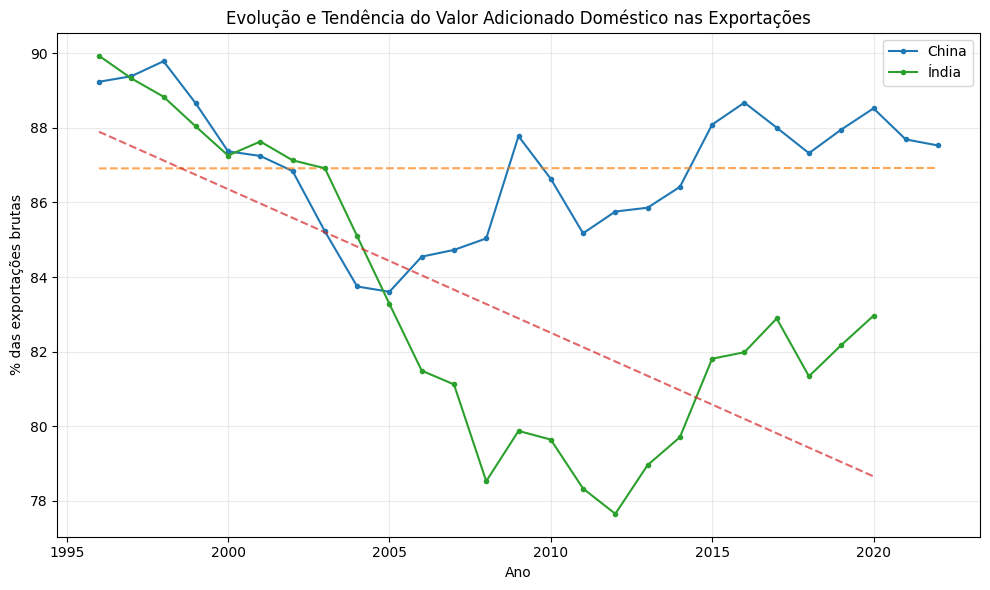


MATRIZ DE CORRELAÇÃO


,ln_DVA_SHARE,PTF,HumanCapital,ln_PIBpc,RD,ECI
ln_DVA_SHARE,1.000,-0.074,0.101,0.104,0.125,0.149
PTF,-0.074,1.000,0.747,0.796,0.748,0.692
HumanCapital,0.101,0.747,1.000,0.983,0.857,0.960
ln_PIBpc,0.104,0.796,0.983,1.000,0.924,0.980
RD,0.125,0.748,0.857,0.924,1.000,0.932
ECI,0.149,0.692,0.960,0.980,0.932,1.000


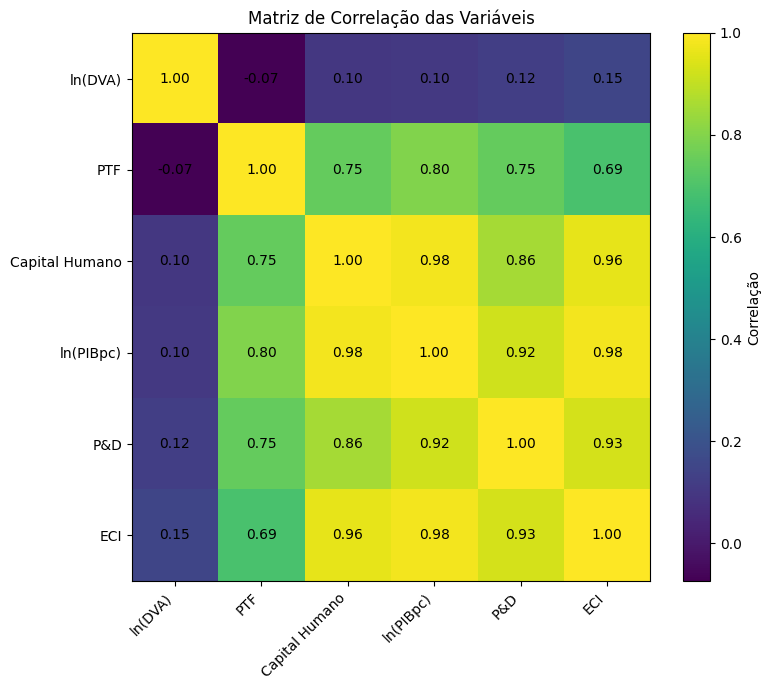


SETORES COM MENOR DVA MÉDIO


,country,País,sector,DVA_SHARE
99,IND,Índia,C19,48.783600
100,IND,Índia,C19T23,61.873400
132,IND,Índia,H50,63.517720
107,IND,Índia,C241_2431,64.752120
133,IND,Índia,H51,65.291960
106,IND,Índia,C24,65.405400
32,CHN,China,C26,67.800519
109,IND,Índia,C24_25,67.924080
108,IND,Índia,C242_2432,67.973720
111,IND,Índia,C26,68.121320



SETORES COM MAIOR DVA MÉDIO


,country,País,sector,DVA_SHARE
82,IND,Índia,A02,98.091600
81,IND,Índia,A01_02,97.527520
74,CHN,China,R,97.484148
79,IND,Índia,A,97.475760
65,CHN,China,L,97.411259
80,IND,Índia,A01,97.159440
75,CHN,China,RTT,96.982444
76,CHN,China,R_S,96.982444
83,IND,Índia,A03,96.422800
144,IND,Índia,L,96.407960



CHECK FINAL — BLOCO 3
Base usada: 4108 observações
Série anual: 52 observações país-ano
Países: ['China' 'Índia']
Período: 1996 - 2022

Arquivos gráficos criados:
OK - grafico_DVA_share.png
OK - grafico_PTF.png
OK - grafico_capital_humano.png
OK - grafico_PIBpc.png
OK - grafico_RD.png
OK - grafico_ECI.png
OK - boxplot_DVA.png
OK - grafico_DVA_tendencia.png
OK - matriz_correlacao.png

Descritivas salvas em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/DESCRITIVAS_TCC.xlsx

BLOCO 3 CONCLUÍDO


In [48]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# BLOCO 3
# ESTATÍSTICAS DESCRITIVAS + GRÁFICOS
# ======================================================================


# ======================================================================
# 1. NOMES DOS PAÍSES PARA OS GRÁFICOS
# ======================================================================

base_graficos = base_final.copy()

mapa_paises = {
    "CHN": "China",
    "IND": "Índia"
}

base_graficos["País"] = (
    base_graficos["country"]
    .map(mapa_paises)
)


# ======================================================================
# 2. ESTATÍSTICAS DESCRITIVAS GERAIS
# ======================================================================

variaveis_descritivas = [
    "DVA_SHARE",
    "PTF",
    "HumanCapital",
    "PIBpc",
    "RD",
    "ECI"
]

descritivas = (
    base_graficos[
        variaveis_descritivas
    ]
    .describe()
    .T
)

descritivas = descritivas[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(3)


descritivas = descritivas.rename(
    index={
        "DVA_SHARE":
        "DVA nas exportações (%)",

        "PTF":
        "Produtividade Total dos Fatores",

        "HumanCapital":
        "Capital Humano",

        "PIBpc":
        "PIB per capita",

        "RD":
        "P&D (% do PIB)",

        "ECI":
        "Complexidade Econômica"
    }
)


print("=" * 90)
print("ESTATÍSTICAS DESCRITIVAS — AMOSTRA ECONOMÉTRICA")
print("=" * 90)

display(
    descritivas
)


# ======================================================================
# 3. ESTATÍSTICAS POR PAÍS
# ======================================================================

descritivas_pais = (
    base_graficos
    .groupby("País")[
        variaveis_descritivas
    ]
    .mean()
    .round(3)
)

descritivas_pais = descritivas_pais.rename(
    columns={
        "DVA_SHARE":
        "DVA nas exportações (%)",

        "PTF":
        "PTF",

        "HumanCapital":
        "Capital Humano",

        "PIBpc":
        "PIB per capita",

        "RD":
        "P&D (% PIB)",

        "ECI":
        "ECI"
    }
)


print("\n" + "=" * 90)
print("MÉDIAS POR PAÍS")
print("=" * 90)

display(
    descritivas_pais
)


# ======================================================================
# 4. BASE ANUAL
#
# DVA varia por setor.
# Para os gráficos nacionais, calculamos a média dos setores por ano.
#
# As demais variáveis são país-ano e aparecem repetidas entre setores.
# Por isso usamos "first" para não alterar seu valor.
# ======================================================================

anual = (
    base_graficos
    .groupby(
        [
            "country",
            "País",
            "year"
        ]
    )
    .agg(
        DVA_SHARE=(
            "DVA_SHARE",
            "mean"
        ),

        PTF=(
            "PTF",
            "first"
        ),

        HumanCapital=(
            "HumanCapital",
            "first"
        ),

        PIBpc=(
            "PIBpc",
            "first"
        ),

        RD=(
            "RD",
            "first"
        ),

        ECI=(
            "ECI",
            "first"
        )
    )
    .reset_index()
)


print("\n" + "=" * 90)
print("BASE ANUAL PARA OS GRÁFICOS")
print("=" * 90)

print(
    "Observações:",
    len(anual)
)

print(
    "Período:",
    anual["year"].min(),
    "-",
    anual["year"].max()
)

display(
    anual.head()
)


# ======================================================================
# 5. FUNÇÃO PARA GRÁFICOS TEMPORAIS
# ======================================================================

def grafico_linha(
    dados,
    variavel,
    titulo,
    ylabel,
    nome_arquivo
):

    plt.figure(
        figsize=(10, 6)
    )

    for pais in [
        "China",
        "Índia"
    ]:

        temp = (
            dados[
                dados["País"] == pais
            ]
            .sort_values("year")
        )

        plt.plot(
            temp["year"],
            temp[variavel],
            marker="o",
            markersize=3,
            linewidth=2,
            label=pais
        )

    plt.title(
        titulo,
        fontsize=13
    )

    plt.xlabel(
        "Ano"
    )

    plt.ylabel(
        ylabel
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    caminho = (
        f"{PASTA}/{nome_arquivo}"
    )

    plt.savefig(
        caminho,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Gráfico salvo em:",
        caminho
    )


# ======================================================================
# 6. GRÁFICO — DVA NAS EXPORTAÇÕES
# ======================================================================

grafico_linha(
    anual,

    "DVA_SHARE",

    "Participação do Valor Adicionado Doméstico nas Exportações",

    "% das exportações brutas",

    "grafico_DVA_share.png"
)


# ======================================================================
# 7. GRÁFICO — PRODUTIVIDADE TOTAL DOS FATORES
# ======================================================================

grafico_linha(
    anual,

    "PTF",

    "Produtividade Total dos Fatores",

    "Índice de PTF",

    "grafico_PTF.png"
)


# ======================================================================
# 8. GRÁFICO — CAPITAL HUMANO
# ======================================================================

grafico_linha(
    anual,

    "HumanCapital",

    "Índice de Capital Humano",

    "Índice de capital humano",

    "grafico_capital_humano.png"
)


# ======================================================================
# 9. GRÁFICO — PIB PER CAPITA
# ======================================================================

grafico_linha(
    anual,

    "PIBpc",

    "PIB per capita",

    "PIB per capita",

    "grafico_PIBpc.png"
)


# ======================================================================
# 10. GRÁFICO — P&D
# ======================================================================

grafico_linha(
    anual,

    "RD",

    "Gastos em Pesquisa e Desenvolvimento",

    "P&D (% do PIB)",

    "grafico_RD.png"
)


# ======================================================================
# 11. GRÁFICO — COMPLEXIDADE ECONÔMICA
# ======================================================================

grafico_linha(
    anual,

    "ECI",

    "Índice de Complexidade Econômica",

    "ECI",

    "grafico_ECI.png"
)


# ======================================================================
# 12. DVA POR PAÍS — DISTRIBUIÇÃO
# ======================================================================

dados_china = (
    base_graficos[
        base_graficos["country"] == "CHN"
    ]["DVA_SHARE"]
    .dropna()
)

dados_india = (
    base_graficos[
        base_graficos["country"] == "IND"
    ]["DVA_SHARE"]
    .dropna()
)


plt.figure(
    figsize=(8, 6)
)

plt.boxplot(
    [
        dados_china,
        dados_india
    ],
    tick_labels=[
        "China",
        "Índia"
    ]
)

plt.title(
    "Distribuição da Participação do Valor Adicionado Doméstico"
)

plt.ylabel(
    "% das exportações brutas"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    f"{PASTA}/boxplot_DVA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ======================================================================
# 13. EVOLUÇÃO DO DVA POR PAÍS
#     COM LINHA DE TENDÊNCIA
# ======================================================================

plt.figure(
    figsize=(10, 6)
)

for pais in [
    "China",
    "Índia"
]:

    temp = (
        anual[
            anual["País"] == pais
        ]
        .sort_values("year")
    )

    plt.plot(
        temp["year"],
        temp["DVA_SHARE"],
        marker="o",
        markersize=3,
        label=pais
    )

    # tendência linear apenas para visualização
    coef = np.polyfit(
        temp["year"],
        temp["DVA_SHARE"],
        1
    )

    tendencia = np.polyval(
        coef,
        temp["year"]
    )

    plt.plot(
        temp["year"],
        tendencia,
        linestyle="--",
        alpha=0.7
    )


plt.title(
    "Evolução e Tendência do Valor Adicionado Doméstico nas Exportações"
)

plt.xlabel(
    "Ano"
)

plt.ylabel(
    "% das exportações brutas"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    f"{PASTA}/grafico_DVA_tendencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ======================================================================
# 14. MATRIZ DE CORRELAÇÃO
# ======================================================================

variaveis_correlacao = [
    "ln_DVA_SHARE",
    "PTF",
    "HumanCapital",
    "ln_PIBpc",
    "RD",
    "ECI"
]

correlacao = (
    base_graficos[
        variaveis_correlacao
    ]
    .corr()
    .round(3)
)


print("\n" + "=" * 90)
print("MATRIZ DE CORRELAÇÃO")
print("=" * 90)

display(
    correlacao
)


# ======================================================================
# 15. MAPA VISUAL DA CORRELAÇÃO
# ======================================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

imagem = ax.imshow(
    correlacao.values,
    aspect="auto"
)

ax.set_xticks(
    range(
        len(
            correlacao.columns
        )
    )
)

ax.set_yticks(
    range(
        len(
            correlacao.index
        )
    )
)

nomes_corr = [
    "ln(DVA)",
    "PTF",
    "Capital Humano",
    "ln(PIBpc)",
    "P&D",
    "ECI"
]

ax.set_xticklabels(
    nomes_corr,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    nomes_corr
)


for i in range(
    len(
        correlacao.index
    )
):

    for j in range(
        len(
            correlacao.columns
        )
    ):

        ax.text(
            j,
            i,
            f"{correlacao.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )


plt.colorbar(
    imagem,
    ax=ax,
    label="Correlação"
)

plt.title(
    "Matriz de Correlação das Variáveis"
)

plt.tight_layout()

plt.savefig(
    f"{PASTA}/matriz_correlacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ======================================================================
# 16. MÉDIA DO DVA POR SETOR
# ======================================================================

dva_setor = (
    base_graficos
    .groupby(
        [
            "country",
            "País",
            "sector"
        ]
    )["DVA_SHARE"]
    .mean()
    .reset_index()
)


print("\n" + "=" * 90)
print("SETORES COM MENOR DVA MÉDIO")
print("=" * 90)

display(
    dva_setor
    .sort_values(
        "DVA_SHARE"
    )
    .head(15)
)


print("\n" + "=" * 90)
print("SETORES COM MAIOR DVA MÉDIO")
print("=" * 90)

display(
    dva_setor
    .sort_values(
        "DVA_SHARE",
        ascending=False
    )
    .head(15)
)


# ======================================================================
# 17. EXPORTAR AS DESCRITIVAS
# ======================================================================

ARQUIVO_DESCRITIVAS = (
    f"{PASTA}/DESCRITIVAS_TCC.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_DESCRITIVAS,
    engine="openpyxl"
) as writer:

    descritivas.to_excel(
        writer,
        sheet_name="Descritivas gerais"
    )

    descritivas_pais.to_excel(
        writer,
        sheet_name="Medias por pais"
    )

    correlacao.to_excel(
        writer,
        sheet_name="Correlacao"
    )

    anual.to_excel(
        writer,
        sheet_name="Series anuais",
        index=False
    )

    dva_setor.to_excel(
        writer,
        sheet_name="DVA por setor",
        index=False
    )


# ======================================================================
# 18. CHECK FINAL
# ======================================================================

print("\n" + "=" * 90)
print("CHECK FINAL — BLOCO 3")
print("=" * 90)

print(
    "Base usada:",
    len(base_graficos),
    "observações"
)

print(
    "Série anual:",
    len(anual),
    "observações país-ano"
)

print(
    "Países:",
    anual["País"].unique()
)

print(
    "Período:",
    anual["year"].min(),
    "-",
    anual["year"].max()
)


print("\nArquivos gráficos criados:")

arquivos_graficos = [
    "grafico_DVA_share.png",
    "grafico_PTF.png",
    "grafico_capital_humano.png",
    "grafico_PIBpc.png",
    "grafico_RD.png",
    "grafico_ECI.png",
    "boxplot_DVA.png",
    "grafico_DVA_tendencia.png",
    "matriz_correlacao.png"
]

for arquivo in arquivos_graficos:

    existe = os.path.exists(
        f"{PASTA}/{arquivo}"
    )

    print(
        "OK" if existe else "ERRO",
        "-",
        arquivo
    )


print(
    "\nDescritivas salvas em:"
)

print(
    ARQUIVO_DESCRITIVAS
)


print("\n" + "=" * 90)
print("BLOCO 3 CONCLUÍDO")
print("=" * 90)

In [49]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# BLOCO 4
# DIAGNÓSTICO DE MULTICOLINEARIDADE
# ======================================================================


# ======================================================================
# 1. VARIÁVEIS EXPLICATIVAS
# ======================================================================

variaveis_x = [
    "PTF",
    "HumanCapital",
    "ln_PIBpc",
    "RD",
    "ECI"
]


# ======================================================================
# 2. BASE PARA O DIAGNÓSTICO
# ======================================================================

base_vif = (
    base_final[
        variaveis_x
    ]
    .dropna()
    .copy()
)


print("=" * 80)
print("DIAGNÓSTICO DE MULTICOLINEARIDADE")
print("=" * 80)

print(
    "Observações utilizadas:",
    len(base_vif)
)


# ======================================================================
# 3. MATRIZ DE CORRELAÇÃO DAS EXPLICATIVAS
# ======================================================================

corr_x = (
    base_vif
    .corr()
    .round(3)
)


print("\n" + "=" * 80)
print("CORRELAÇÃO ENTRE AS VARIÁVEIS EXPLICATIVAS")
print("=" * 80)

display(
    corr_x
)


# ======================================================================
# 4. VIF — MODELO COMPLETO
# ======================================================================

X_vif = sm.add_constant(
    base_vif
)


vif_completo = pd.DataFrame({
    "Variável":
    X_vif.columns,

    "VIF":
    [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(
            X_vif.shape[1]
        )
    ]
})


# Retirar constante da tabela principal
vif_completo = (
    vif_completo[
        vif_completo["Variável"]
        != "const"
    ]
    .copy()
)


vif_completo["VIF"] = (
    vif_completo["VIF"]
    .round(2)
)


vif_completo = (
    vif_completo
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("VIF — ESPECIFICAÇÃO COMPLETA")
print("=" * 80)

display(
    vif_completo
)


# ======================================================================
# 5. CLASSIFICAÇÃO APENAS PARA DIAGNÓSTICO
#
# VIF < 5  : geralmente pouco preocupante
# 5 a 10   : atenção
# > 10     : multicolinearidade elevada
#
# Esses limites são referências práticas, não regras mecânicas.
# ======================================================================

def classificar_vif(valor):

    if valor < 5:
        return "Baixo"

    elif valor < 10:
        return "Atenção"

    else:
        return "Elevado"


vif_completo["Diagnóstico"] = (
    vif_completo["VIF"]
    .apply(classificar_vif)
)


print("\n" + "=" * 80)
print("CLASSIFICAÇÃO DO VIF")
print("=" * 80)

display(
    vif_completo
)


# ======================================================================
# 6. CORRELAÇÕES MUITO ALTAS
# ======================================================================

pares_correlacao = []


for i in range(
    len(variaveis_x)
):

    for j in range(
        i + 1,
        len(variaveis_x)
    ):

        var1 = variaveis_x[i]
        var2 = variaveis_x[j]

        correlacao = corr_x.loc[
            var1,
            var2
        ]

        if abs(correlacao) >= 0.80:

            pares_correlacao.append({
                "Variável 1": var1,
                "Variável 2": var2,
                "Correlação": correlacao
            })


correlacoes_altas = pd.DataFrame(
    pares_correlacao
)


if len(correlacoes_altas) > 0:

    correlacoes_altas = (
        correlacoes_altas
        .assign(
            Abs_correlacao=lambda x:
            x["Correlação"].abs()
        )
        .sort_values(
            "Abs_correlacao",
            ascending=False
        )
        .drop(
            columns="Abs_correlacao"
        )
        .reset_index(drop=True)
    )


print("\n" + "=" * 80)
print("PARES COM |CORRELAÇÃO| >= 0,80")
print("=" * 80)

if len(correlacoes_altas) > 0:

    display(
        correlacoes_altas
    )

else:

    print(
        "Nenhum par encontrado."
    )


# ======================================================================
# 7. NÃO REMOVER VARIÁVEIS AUTOMATICAMENTE
# ======================================================================

print("\n" + "=" * 80)
print("IMPORTANTE")
print("=" * 80)

print(
    """
O VIF é utilizado aqui como diagnóstico.

Nenhuma variável será excluída automaticamente
por apresentar VIF elevado.

A definição das especificações econométricas será
feita considerando conjuntamente:

1. fundamentação teórica;
2. objetivo do TCC;
3. correlação entre as variáveis;
4. VIF;
5. estrutura país-setor-ano dos dados.

Não serão escolhidas variáveis com base apenas
na significância estatística.
"""
)


# ======================================================================
# 8. SALVAR DIAGNÓSTICO
# ======================================================================

ARQUIVO_VIF = (
    f"{PASTA}/DIAGNOSTICO_MULTICOLINEARIDADE.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_VIF,
    engine="openpyxl"
) as writer:

    corr_x.to_excel(
        writer,
        sheet_name="Correlacao"
    )

    vif_completo.to_excel(
        writer,
        sheet_name="VIF",
        index=False
    )

    if len(correlacoes_altas) > 0:

        correlacoes_altas.to_excel(
            writer,
            sheet_name="Correlacoes altas",
            index=False
        )


# ======================================================================
# 9. CHECK
# ======================================================================

print("\n" + "=" * 80)
print("CHECK FINAL — BLOCO 4")
print("=" * 80)

print(
    "Maior VIF:",
    vif_completo.iloc[0]["Variável"],
    "=",
    vif_completo.iloc[0]["VIF"]
)

print(
    "Número de variáveis com VIF > 10:",
    (
        vif_completo["VIF"] > 10
    ).sum()
)

print(
    "Número de pares com |correlação| >= 0,80:",
    len(correlacoes_altas)
)

print(
    "\nArquivo salvo em:"
)

print(
    ARQUIVO_VIF
)

print("\n" + "=" * 80)
print("BLOCO 4 CONCLUÍDO")
print("=" * 80)

DIAGNÓSTICO DE MULTICOLINEARIDADE
Observações utilizadas: 4108

CORRELAÇÃO ENTRE AS VARIÁVEIS EXPLICATIVAS


,PTF,HumanCapital,ln_PIBpc,RD,ECI
PTF,1.000,0.747,0.796,0.748,0.692
HumanCapital,0.747,1.000,0.983,0.857,0.960
ln_PIBpc,0.796,0.983,1.000,0.924,0.980
RD,0.748,0.857,0.924,1.000,0.932
ECI,0.692,0.960,0.980,0.932,1.000



VIF — ESPECIFICAÇÃO COMPLETA


,Variável,VIF
0,ln_PIBpc,297.47
1,HumanCapital,86.38
2,ECI,85.50
3,RD,18.47
4,PTF,9.33



CLASSIFICAÇÃO DO VIF


,Variável,VIF,Diagnóstico
0,ln_PIBpc,297.47,Elevado
1,HumanCapital,86.38,Elevado
2,ECI,85.50,Elevado
3,RD,18.47,Elevado
4,PTF,9.33,Atenção



PARES COM |CORRELAÇÃO| >= 0,80


,Variável 1,Variável 2,Correlação
0,HumanCapital,ln_PIBpc,0.983
1,ln_PIBpc,ECI,0.980
2,HumanCapital,ECI,0.960
3,RD,ECI,0.932
4,ln_PIBpc,RD,0.924
5,HumanCapital,RD,0.857



IMPORTANTE

O VIF é utilizado aqui como diagnóstico.

Nenhuma variável será excluída automaticamente
por apresentar VIF elevado.

A definição das especificações econométricas será
feita considerando conjuntamente:

1. fundamentação teórica;
2. objetivo do TCC;
3. correlação entre as variáveis;
4. VIF;
5. estrutura país-setor-ano dos dados.

Não serão escolhidas variáveis com base apenas
na significância estatística.


CHECK FINAL — BLOCO 4
Maior VIF: ln_PIBpc = 297.47
Número de variáveis com VIF > 10: 4
Número de pares com |correlação| >= 0,80: 6

Arquivo salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/DIAGNOSTICO_MULTICOLINEARIDADE.xlsx

BLOCO 4 CONCLUÍDO


In [50]:
display(vif_completo)

,Variável,VIF,Diagnóstico
0,ln_PIBpc,297.47,Elevado
1,HumanCapital,86.38,Elevado
2,ECI,85.50,Elevado
3,RD,18.47,Elevado
4,PTF,9.33,Atenção


In [51]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# BLOCO 5
# VIF DAS ESPECIFICAÇÕES ALTERNATIVAS
# ======================================================================


# ======================================================================
# 1. DEFINIÇÃO DAS ESPECIFICAÇÕES
# ======================================================================

especificacoes = {

    # Modelo-base:
    # produtividade + capital humano
    "Modelo 1 — Controles": [
        "PTF",
        "HumanCapital"
    ],

    # Inovação:
    # acrescenta P&D
    "Modelo 2 — Inovação": [
        "PTF",
        "HumanCapital",
        "RD"
    ],

    # Complexidade:
    # acrescenta ECI
    "Modelo 3 — Complexidade": [
        "PTF",
        "HumanCapital",
        "ECI"
    ],

    # Variáveis centrais do trabalho:
    # inovação + complexidade
    "Modelo 4 — Inovação + Complexidade": [
        "PTF",
        "RD",
        "ECI"
    ]
}


# ======================================================================
# 2. FUNÇÃO PARA CALCULAR VIF
# ======================================================================

def calcular_vif(dados, variaveis):

    # Usa apenas observações completas
    temp = (
        dados[variaveis]
        .dropna()
        .copy()
    )

    # Adiciona constante
    X = sm.add_constant(temp)

    resultados = []

    for i, coluna in enumerate(X.columns):

        if coluna == "const":
            continue

        valor_vif = variance_inflation_factor(
            X.values,
            i
        )

        resultados.append({
            "Variável": coluna,
            "VIF": valor_vif
        })

    tabela = pd.DataFrame(
        resultados
    )

    tabela["VIF"] = (
        tabela["VIF"]
        .round(2)
    )

    tabela = (
        tabela
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return tabela


# ======================================================================
# 3. CALCULAR VIF PARA CADA ESPECIFICAÇÃO
# ======================================================================

resultados_vif = {}

print("=" * 85)
print("VIF DAS ESPECIFICAÇÕES ALTERNATIVAS")
print("=" * 85)


for nome_modelo, variaveis in especificacoes.items():

    tabela = calcular_vif(
        base_final,
        variaveis
    )

    resultados_vif[nome_modelo] = tabela

    print("\n" + "=" * 85)
    print(nome_modelo)
    print("=" * 85)

    print(
        "Variáveis:",
        " + ".join(variaveis)
    )

    display(
        tabela
    )


# ======================================================================
# 4. CRIAR RESUMO DOS MAIORES VIFs
# ======================================================================

resumo_vif = []


for nome_modelo, tabela in resultados_vif.items():

    maior_vif = (
        tabela["VIF"].max()
    )

    variavel_maior = (
        tabela.loc[
            tabela["VIF"].idxmax(),
            "Variável"
        ]
    )

    # Classificação apenas como referência prática
    if maior_vif < 5:

        diagnostico = "Baixo"

    elif maior_vif < 10:

        diagnostico = "Atenção"

    else:

        diagnostico = "Elevado"


    resumo_vif.append({

        "Modelo":
        nome_modelo,

        "Maior VIF":
        maior_vif,

        "Variável com maior VIF":
        variavel_maior,

        "Diagnóstico":
        diagnostico
    })


resumo_vif = pd.DataFrame(
    resumo_vif
)


print("\n" + "=" * 85)
print("RESUMO DAS ESPECIFICAÇÕES")
print("=" * 85)

display(
    resumo_vif
)


# ======================================================================
# 5. CORRELAÇÕES DENTRO DE CADA MODELO
# ======================================================================

print("\n" + "=" * 85)
print("CORRELAÇÕES DENTRO DE CADA ESPECIFICAÇÃO")
print("=" * 85)


for nome_modelo, variaveis in especificacoes.items():

    print("\n" + "-" * 85)
    print(nome_modelo)
    print("-" * 85)

    matriz = (
        base_final[
            variaveis
        ]
        .corr()
        .round(3)
    )

    display(
        matriz
    )


# ======================================================================
# 6. COMPARAÇÃO COM O MODELO COMPLETO ORIGINAL
# ======================================================================

print("\n" + "=" * 85)
print("COMPARAÇÃO COM A ESPECIFICAÇÃO COMPLETA")
print("=" * 85)

print(
    """
Especificação completa anterior:

PTF + HumanCapital + ln_PIBpc + RD + ECI

Maior VIF encontrado:
ln_PIBpc = 297,47

O objetivo das especificações alternativas é verificar
se a separação de variáveis fortemente correlacionadas
reduz o problema de multicolinearidade.
"""
)


# ======================================================================
# 7. NÃO ESCOLHER MODELO AUTOMATICAMENTE
# ======================================================================

print("=" * 85)
print("REGRA PARA A PRÓXIMA ETAPA")
print("=" * 85)

print(
    """
Este bloco NÃO escolhe automaticamente o modelo final.

A decisão será feita considerando:

1. objetivo teórico do TCC;
2. importância de P&D e ECI para a pergunta de pesquisa;
3. magnitude dos VIFs;
4. correlação entre as explicativas;
5. parcimônia da especificação.

Nenhuma especificação será escolhida porque produz
maior significância estatística.
"""
)


# ======================================================================
# 8. EXPORTAR RESULTADOS
# ======================================================================

ARQUIVO_VIF_MODELOS = (
    f"{PASTA}/VIF_ESPECIFICACOES_TCC.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_VIF_MODELOS,
    engine="openpyxl"
) as writer:

    resumo_vif.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    for numero, (nome_modelo, tabela) in enumerate(
        resultados_vif.items(),
        start=1
    ):

        tabela.to_excel(
            writer,
            sheet_name=f"Modelo {numero}",
            index=False
        )


# ======================================================================
# 9. CHECK FINAL
# ======================================================================

print("\n" + "=" * 85)
print("CHECK FINAL — BLOCO 5")
print("=" * 85)


for _, linha in resumo_vif.iterrows():

    print(
        f"{linha['Modelo']}: "
        f"maior VIF = {linha['Maior VIF']} "
        f"({linha['Variável com maior VIF']})"
    )


print(
    "\nArquivo salvo em:"
)

print(
    ARQUIVO_VIF_MODELOS
)

print("\n" + "=" * 85)
print("BLOCO 5 CONCLUÍDO")
print("=" * 85)

VIF DAS ESPECIFICAÇÕES ALTERNATIVAS

Modelo 1 — Controles
Variáveis: PTF + HumanCapital


,Variável,VIF
0,PTF,2.26
1,HumanCapital,2.26



Modelo 2 — Inovação
Variáveis: PTF + HumanCapital + RD


,Variável,VIF
0,RD,4.18
1,HumanCapital,4.17
2,PTF,2.51



Modelo 3 — Complexidade
Variáveis: PTF + HumanCapital + ECI


...


-------------------------------------------------------------------------------------
Modelo 3 — Complexidade
-------------------------------------------------------------------------------------


,PTF,HumanCapital,ECI
PTF,1.000,0.747,0.692
HumanCapital,0.747,1.000,0.960
ECI,0.692,0.960,1.000



-------------------------------------------------------------------------------------
Modelo 4 — Inovação + Complexidade
-------------------------------------------------------------------------------------


,PTF,RD,ECI
PTF,1.000,0.748,0.692
RD,0.748,1.000,0.932
ECI,0.692,0.932,1.000



COMPARAÇÃO COM A ESPECIFICAÇÃO COMPLETA

Especificação completa anterior:

PTF + HumanCapital + ln_PIBpc + RD + ECI

Maior VIF encontrado:
ln_PIBpc = 297,47

O objetivo das especificações alternativas é verificar
se a separação de variáveis fortemente correlacionadas
reduz o problema de multicolinearidade.

REGRA PARA A PRÓXIMA ETAPA

Este bloco NÃO escolhe automaticamente o modelo final.

A decisão será feita considerando:

1. objetivo teórico do TCC;
2. importância de P&D e ECI para a pergunta de pesquisa;
3. magnitude dos VIFs;
4. correlação entre as explicativas;
5. parcimônia da especificação.

Nenhuma especificação será escolhida porque produz
maior significância estatística.


CHECK FINAL — BLOCO 5
Modelo 1 — Controles: maior VIF = 2.26 (PTF)
Modelo 2 — Inovação: maior VIF = 4.18 (RD)
Modelo 3 — Complexidade: maior VIF = 15.4 (HumanCapital)
Modelo 4 — Inovação + Complexidade: maior VIF = 9.02 (RD)

Arquivo salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados 

In [52]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# BLOCO 6
# ESTIMAÇÕES ECONOMÉTRICAS
# ======================================================================

from linearmodels.panel import PanelOLS


# ======================================================================
# 1. PREPARAR O PAINEL
# ======================================================================

painel_econ = (
    base_final
    .set_index(["entity", "year"])
    .sort_index()
)


print("=" * 80)
print("PAINEL ECONOMÉTRICO")
print("=" * 80)

print(
    "Observações:",
    len(painel_econ)
)

print(
    "Entidades país-setor:",
    base_final["entity"].nunique()
)

print(
    "Período:",
    base_final["year"].min(),
    "-",
    base_final["year"].max()
)


# ======================================================================
# 2. MODELO 1 — CONTROLES
#
# PTF + Capital Humano
# ======================================================================

modelo1_fe = PanelOLS.from_formula(
    "ln_DVA_SHARE ~ "
    "PTF + "
    "HumanCapital + "
    "EntityEffects",

    data=painel_econ
)

resultado1_fe = modelo1_fe.fit(
    cov_type="robust"
)


print("\n" + "=" * 80)
print("MODELO 1 — CONTROLES")
print("EFEITOS FIXOS PAÍS-SETOR")
print("=" * 80)

print(
    resultado1_fe.summary
)


# ======================================================================
# 3. MODELO 2 — INOVAÇÃO
#
# PTF + Capital Humano + P&D
#
# Esta será nossa especificação-base.
# ======================================================================

modelo2_fe = PanelOLS.from_formula(
    "ln_DVA_SHARE ~ "
    "PTF + "
    "HumanCapital + "
    "RD + "
    "EntityEffects",

    data=painel_econ
)

resultado2_fe = modelo2_fe.fit(
    cov_type="robust"
)


print("\n" + "=" * 80)
print("MODELO 2 — INOVAÇÃO")
print("EFEITOS FIXOS PAÍS-SETOR")
print("=" * 80)

print(
    resultado2_fe.summary
)


# ======================================================================
# 4. MODELO 4 — INOVAÇÃO + COMPLEXIDADE
#
# PTF + P&D + ECI
#
# Não usamos capital humano junto com ECI nesta especificação
# devido à elevada multicolinearidade encontrada anteriormente.
# ======================================================================

modelo4_fe = PanelOLS.from_formula(
    "ln_DVA_SHARE ~ "
    "PTF + "
    "RD + "
    "ECI + "
    "EntityEffects",

    data=painel_econ
)

resultado4_fe = modelo4_fe.fit(
    cov_type="robust"
)


print("\n" + "=" * 80)
print("MODELO 3 — INOVAÇÃO + COMPLEXIDADE")
print("EFEITOS FIXOS PAÍS-SETOR")
print("=" * 80)

print(
    resultado4_fe.summary
)


# ======================================================================
# 5. AGORA AS MESMAS ESPECIFICAÇÕES COM EFEITOS DE ANO
#
# Isso controla fatores comuns a China e Índia em cada ano.
# ======================================================================


# ----------------------------------------------------------------------
# Modelo 1 + ano
# ----------------------------------------------------------------------

modelo1_time = PanelOLS.from_formula(
    "ln_DVA_SHARE ~ "
    "PTF + "
    "HumanCapital + "
    "EntityEffects + "
    "TimeEffects",

    data=painel_econ
)

resultado1_time = modelo1_time.fit(
    cov_type="robust"
)


# ----------------------------------------------------------------------
# Modelo 2 + ano
# ----------------------------------------------------------------------

modelo2_time = PanelOLS.from_formula(
    "ln_DVA_SHARE ~ "
    "PTF + "
    "HumanCapital + "
    "RD + "
    "EntityEffects + "
    "TimeEffects",

    data=painel_econ
)

resultado2_time = modelo2_time.fit(
    cov_type="robust"
)


# ----------------------------------------------------------------------
# Modelo 3 + ano
# ----------------------------------------------------------------------

modelo4_time = PanelOLS.from_formula(
    "ln_DVA_SHARE ~ "
    "PTF + "
    "RD + "
    "ECI + "
    "EntityEffects + "
    "TimeEffects",

    data=painel_econ
)

resultado4_time = modelo4_time.fit(
    cov_type="robust"
)


# ======================================================================
# 6. MOSTRAR RESULTADOS COM EFEITOS DE ANO
# ======================================================================

print("\n" + "=" * 80)
print("MODELO 1 — CONTROLES + EFEITOS DE ANO")
print("=" * 80)

print(
    resultado1_time.summary
)


print("\n" + "=" * 80)
print("MODELO 2 — INOVAÇÃO + EFEITOS DE ANO")
print("=" * 80)

print(
    resultado2_time.summary
)


print("\n" + "=" * 80)
print("MODELO 3 — INOVAÇÃO + COMPLEXIDADE + EFEITOS DE ANO")
print("=" * 80)

print(
    resultado4_time.summary
)


# ======================================================================
# 7. FUNÇÃO SIMPLES PARA RESUMIR COEFICIENTES
# ======================================================================

def resumo_modelo(resultado, nome):

    linhas = []

    for variavel in resultado.params.index:

        coef = resultado.params[variavel]
        p = resultado.pvalues[variavel]

        if p < 0.01:
            sig = "***"

        elif p < 0.05:
            sig = "**"

        elif p < 0.10:
            sig = "*"

        else:
            sig = ""


        linhas.append({
            "Modelo": nome,
            "Variável": variavel,
            "Coeficiente": round(coef, 4),
            "Erro padrão": round(
                resultado.std_errors[variavel],
                4
            ),
            "p-valor": round(p, 4),
            "Significância": sig
        })

    return pd.DataFrame(linhas)


# ======================================================================
# 8. RESUMO DOS SEIS RESULTADOS
# ======================================================================

resumos = pd.concat(
    [
        resumo_modelo(
            resultado1_fe,
            "M1 — Controles"
        ),

        resumo_modelo(
            resultado2_fe,
            "M2 — Inovação"
        ),

        resumo_modelo(
            resultado4_fe,
            "M3 — Inovação + Complexidade"
        ),

        resumo_modelo(
            resultado1_time,
            "M1 + Ano"
        ),

        resumo_modelo(
            resultado2_time,
            "M2 + Ano"
        ),

        resumo_modelo(
            resultado4_time,
            "M3 + Ano"
        )
    ],

    ignore_index=True
)


print("\n" + "=" * 80)
print("RESUMO DOS RESULTADOS")
print("=" * 80)

display(
    resumos
)


# ======================================================================
# 9. CHECK SIMPLES DAS VARIÁVEIS CENTRAIS
# ======================================================================

print("\n" + "=" * 80)
print("RESULTADOS DAS VARIÁVEIS DE MAIOR INTERESSE")
print("=" * 80)


# P&D no Modelo 2
print("\nP&D — Modelo 2:")

print(
    "Coeficiente:",
    round(
        resultado2_fe.params["RD"],
        4
    )
)

print(
    "p-valor:",
    round(
        resultado2_fe.pvalues["RD"],
        4
    )
)


# P&D no Modelo 3
print("\nP&D — Modelo 3:")

print(
    "Coeficiente:",
    round(
        resultado4_fe.params["RD"],
        4
    )
)

print(
    "p-valor:",
    round(
        resultado4_fe.pvalues["RD"],
        4
    )
)


# ECI no Modelo 3
print("\nECI — Modelo 3:")

print(
    "Coeficiente:",
    round(
        resultado4_fe.params["ECI"],
        4
    )
)

print(
    "p-valor:",
    round(
        resultado4_fe.pvalues["ECI"],
        4
    )
)


# ======================================================================
# 10. SALVAR RESULTADOS
# ======================================================================

ARQUIVO_ECONOMETRIA = (
    f"{PASTA}/RESULTADOS_ECONOMETRICOS_TCC.xlsx"
)


with pd.ExcelWriter(
    ARQUIVO_ECONOMETRIA,
    engine="openpyxl"
) as writer:

    resumos.to_excel(
        writer,
        sheet_name="Resultados",
        index=False
    )


# ======================================================================
# 11. SALVAR OS SUMÁRIOS COMPLETOS
# ======================================================================

with open(
    f"{PASTA}/MODELO_1_FE.txt",
    "w"
) as arquivo:

    arquivo.write(
        str(resultado1_fe.summary)
    )


with open(
    f"{PASTA}/MODELO_2_FE.txt",
    "w"
) as arquivo:

    arquivo.write(
        str(resultado2_fe.summary)
    )


with open(
    f"{PASTA}/MODELO_3_FE.txt",
    "w"
) as arquivo:

    arquivo.write(
        str(resultado4_fe.summary)
    )


with open(
    f"{PASTA}/MODELO_1_TIME.txt",
    "w"
) as arquivo:

    arquivo.write(
        str(resultado1_time.summary)
    )


with open(
    f"{PASTA}/MODELO_2_TIME.txt",
    "w"
) as arquivo:

    arquivo.write(
        str(resultado2_time.summary)
    )


with open(
    f"{PASTA}/MODELO_3_TIME.txt",
    "w"
) as arquivo:

    arquivo.write(
        str(resultado4_time.summary)
    )


# ======================================================================
# 12. CHECK FINAL
# ======================================================================

print("\n" + "=" * 80)
print("CHECK FINAL — BLOCO 6")
print("=" * 80)

print(
    "M1 FE:",
    resultado1_fe.nobs,
    "observações"
)

print(
    "M2 FE:",
    resultado2_fe.nobs,
    "observações"
)

print(
    "M3 FE:",
    resultado4_fe.nobs,
    "observações"
)

print(
    "M1 + Ano:",
    resultado1_time.nobs,
    "observações"
)

print(
    "M2 + Ano:",
    resultado2_time.nobs,
    "observações"
)

print(
    "M3 + Ano:",
    resultado4_time.nobs,
    "observações"
)


print(
    "\nArquivo salvo em:"
)

print(
    ARQUIVO_ECONOMETRIA
)


print("\n" + "=" * 80)
print("BLOCO 6 CONCLUÍDO")
print("=" * 80)

PAINEL ECONOMÉTRICO
Observações: 4108
Entidades país-setor: 158
Período: 1996 - 2022

MODELO 1 — CONTROLES
EFEITOS FIXOS PAÍS-SETOR
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_DVA_SHARE   R-squared:                        0.1172
Estimator:                   PanelOLS   R-squared (Between):             -0.0439
No. Observations:                4108   R-squared (Within):               0.1172
Date:                Mon, Aug 17 2026   R-squared (Overall):             -0.0437
Time:                        22:29:32   Log-likelihood                    6022.2
Cov. Estimator:                Robust                                           
                                        F-statistic:                      262.14
Entities:                         158   P-value                           0.0000
Avg Obs:                       26.000   Distribution:                  F(2,3948)
Min Obs:                       25.000                     

,Modelo,Variável,Coeficiente,Erro padrão,p-valor,Significância
0,M1 — Controles,PTF,-0.6840,0.0474,0.0000,***
1,M1 — Controles,HumanCapital,0.0724,0.0144,0.0000,***
2,M2 — Inovação,PTF,-1.0797,0.0469,0.0000,***
3,M2 — Inovação,HumanCapital,0.0470,0.0137,0.0006,***
4,M2 — Inovação,RD,0.0686,0.0032,0.0000,***
5,M3 — Inovação + Complexidade,PTF,-1.1206,0.0376,0.0000,***
6,M3 — Inovação + Complexidade,RD,0.0269,0.0063,0.0000,***
7,M3 — Inovação + Complexidade,ECI,0.1368,0.0161,0.0000,***
8,M1 + Ano,PTF,0.3578,0.0903,0.0001,***
9,M1 + Ano,HumanCapital,-1.9598,0.0878,0.0000,***



RESULTADOS DAS VARIÁVEIS DE MAIOR INTERESSE

P&D — Modelo 2:
Coeficiente: 0.0686
p-valor: 0.0

P&D — Modelo 3:
Coeficiente: 0.0269
p-valor: 0.0

ECI — Modelo 3:
Coeficiente: 0.1368
p-valor: 0.0

CHECK FINAL — BLOCO 6
M1 FE: 4108 observações
M2 FE: 4108 observações
M3 FE: 4108 observações
M1 + Ano: 4108 observações
M2 + Ano: 4108 observações
M3 + Ano: 4108 observações

Arquivo salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/RESULTADOS_ECONOMETRICOS_TCC.xlsx

BLOCO 6 CONCLUÍDO


In [53]:
display(resumos)

,Modelo,Variável,Coeficiente,Erro padrão,p-valor,Significância
0,M1 — Controles,PTF,-0.6840,0.0474,0.0000,***
1,M1 — Controles,HumanCapital,0.0724,0.0144,0.0000,***
2,M2 — Inovação,PTF,-1.0797,0.0469,0.0000,***
3,M2 — Inovação,HumanCapital,0.0470,0.0137,0.0006,***
4,M2 — Inovação,RD,0.0686,0.0032,0.0000,***
5,M3 — Inovação + Complexidade,PTF,-1.1206,0.0376,0.0000,***
6,M3 — Inovação + Complexidade,RD,0.0269,0.0063,0.0000,***
7,M3 — Inovação + Complexidade,ECI,0.1368,0.0161,0.0000,***
8,M1 + Ano,PTF,0.3578,0.0903,0.0001,***
9,M1 + Ano,HumanCapital,-1.9598,0.0878,0.0000,***


In [54]:
# ======================================================================
# TCC — CHINA E ÍNDIA
# BLOCO 7
# TABELA ECONOMÉTRICA FINAL
# ======================================================================


# ======================================================================
# 1. ORGANIZAR OS MODELOS JÁ ESTIMADOS
# ======================================================================

modelos_finais = {
    "M1": resultado1_fe,
    "M2": resultado2_fe,
    "M3": resultado4_fe,
    "M1 + Ano": resultado1_time,
    "M2 + Ano": resultado2_time,
    "M3 + Ano": resultado4_time
}


# ======================================================================
# 2. NOMES DAS VARIÁVEIS PARA A TABELA
# ======================================================================

nomes_variaveis = {
    "PTF": "Produtividade Total dos Fatores",
    "HumanCapital": "Capital Humano",
    "RD": "P&D (% do PIB)",
    "ECI": "Complexidade Econômica"
}


# ======================================================================
# 3. FUNÇÃO PARA COEFICIENTE + SIGNIFICÂNCIA
# ======================================================================

def formatar_coeficiente(resultado, variavel):

    # Variável não pertence ao modelo
    if variavel not in resultado.params.index:
        return "—"

    coef = resultado.params[variavel]
    p = resultado.pvalues[variavel]

    if p < 0.01:
        estrelas = "***"

    elif p < 0.05:
        estrelas = "**"

    elif p < 0.10:
        estrelas = "*"

    else:
        estrelas = ""

    return f"{coef:.4f}{estrelas}"


# ======================================================================
# 4. FUNÇÃO PARA ERRO-PADRÃO
# ======================================================================

def formatar_erro(resultado, variavel):

    if variavel not in resultado.params.index:
        return ""

    erro = resultado.std_errors[variavel]

    return f"({erro:.4f})"


# ======================================================================
# 5. CONSTRUIR A TABELA
# ======================================================================

linhas = []


for variavel in [
    "PTF",
    "HumanCapital",
    "RD",
    "ECI"
]:

    # Linha do coeficiente
    linha_coef = {
        "Variável": nomes_variaveis[variavel]
    }

    for nome_modelo, resultado in modelos_finais.items():

        linha_coef[nome_modelo] = (
            formatar_coeficiente(
                resultado,
                variavel
            )
        )

    linhas.append(
        linha_coef
    )


    # Linha do erro-padrão
    linha_erro = {
        "Variável": ""
    }

    for nome_modelo, resultado in modelos_finais.items():

        linha_erro[nome_modelo] = (
            formatar_erro(
                resultado,
                variavel
            )
        )

    linhas.append(
        linha_erro
    )


# ======================================================================
# 6. ADICIONAR INFORMAÇÕES DOS MODELOS
# ======================================================================

linhas.append({
    "Variável": "",
    "M1": "",
    "M2": "",
    "M3": "",
    "M1 + Ano": "",
    "M2 + Ano": "",
    "M3 + Ano": ""
})


linhas.append({
    "Variável": "Observações",
    "M1": int(resultado1_fe.nobs),
    "M2": int(resultado2_fe.nobs),
    "M3": int(resultado4_fe.nobs),
    "M1 + Ano": int(resultado1_time.nobs),
    "M2 + Ano": int(resultado2_time.nobs),
    "M3 + Ano": int(resultado4_time.nobs)
})


linhas.append({
    "Variável": "Efeitos fixos país-setor",
    "M1": "Sim",
    "M2": "Sim",
    "M3": "Sim",
    "M1 + Ano": "Sim",
    "M2 + Ano": "Sim",
    "M3 + Ano": "Sim"
})


linhas.append({
    "Variável": "Efeitos fixos de ano",
    "M1": "Não",
    "M2": "Não",
    "M3": "Não",
    "M1 + Ano": "Sim",
    "M2 + Ano": "Sim",
    "M3 + Ano": "Sim"
})


# ======================================================================
# 7. TRANSFORMAR EM DATAFRAME
# ======================================================================

tabela_final = pd.DataFrame(
    linhas
)


print("=" * 95)
print("TABELA FINAL — DETERMINANTES DO VALOR ADICIONADO DOMÉSTICO")
print("=" * 95)

display(
    tabela_final
)


# ======================================================================
# 8. EXPORTAR PARA EXCEL
# ======================================================================

ARQUIVO_TABELA_FINAL = (
    f"{PASTA}/TABELA_ECONOMETRICA_FINAL_TCC.xlsx"
)


tabela_final.to_excel(
    ARQUIVO_TABELA_FINAL,
    index=False
)


# ======================================================================
# 9. SALVAR TAMBÉM EM CSV
# ======================================================================

ARQUIVO_TABELA_CSV = (
    f"{PASTA}/TABELA_ECONOMETRICA_FINAL_TCC.csv"
)


tabela_final.to_csv(
    ARQUIVO_TABELA_CSV,
    index=False,
    encoding="utf-8-sig"
)


# ======================================================================
# 10. CHECK FINAL
# ======================================================================

print("\n" + "=" * 95)
print("CHECK FINAL — BLOCO 7")
print("=" * 95)

print(
    "Modelos apresentados:",
    len(modelos_finais)
)

print(
    "Observações em todos os modelos:",
    [
        int(resultado.nobs)
        for resultado in modelos_finais.values()
    ]
)

print(
    "\nTabela Excel salva em:"
)

print(
    ARQUIVO_TABELA_FINAL
)

print(
    "\nTabela CSV salva em:"
)

print(
    ARQUIVO_TABELA_CSV
)

print("\n*** p<0,01 | ** p<0,05 | * p<0,10")
print("Erros-padrão robustos entre parênteses.")

print("\n" + "=" * 95)
print("BLOCO 7 CONCLUÍDO — ECONOMETRIA FINALIZADA")
print("=" * 95)

TABELA FINAL — DETERMINANTES DO VALOR ADICIONADO DOMÉSTICO


,Variável,M1,M2,M3,M1 + Ano,M2 + Ano,M3 + Ano
0,Produtividade Total dos Fatores,-0.6840***,-1.0797***,-1.1206***,0.3578***,-0.3279***,-0.7209***
1,,(0.0474),(0.0469),(0.0376),(0.0903),(0.0937),(0.0896)
2,Capital Humano,0.0724***,0.0470***,—,-1.9598***,-1.3766***,—
3,,(0.0144),(0.0137),,(0.0878),(0.0889),
4,P&D (% do PIB),—,0.0686***,0.0269***,—,0.0569***,0.0012
5,,,(0.0032),(0.0063),,(0.0032),(0.0064)
6,Complexidade Econômica,—,—,0.1368***,—,—,0.2240***
7,,,,(0.0161),,,(0.0183)
8,,,,,,,
9,Observações,4108,4108,4108,4108,4108,4108



CHECK FINAL — BLOCO 7
Modelos apresentados: 6
Observações em todos os modelos: [4108, 4108, 4108, 4108, 4108, 4108]

Tabela Excel salva em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/TABELA_ECONOMETRICA_FINAL_TCC.xlsx

Tabela CSV salva em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/TABELA_ECONOMETRICA_FINAL_TCC.csv

*** p<0,01 | ** p<0,05 | * p<0,10
Erros-padrão robustos entre parênteses.

BLOCO 7 CONCLUÍDO — ECONOMETRIA FINALIZADA


COMPARAÇÃO INTERNACIONAL
Ano: 2022
Países no gráfico: 75


,country,DVA_SHARE,ECI
13,CHN,87.527342,1.455
34,IND,78.422038,0.630


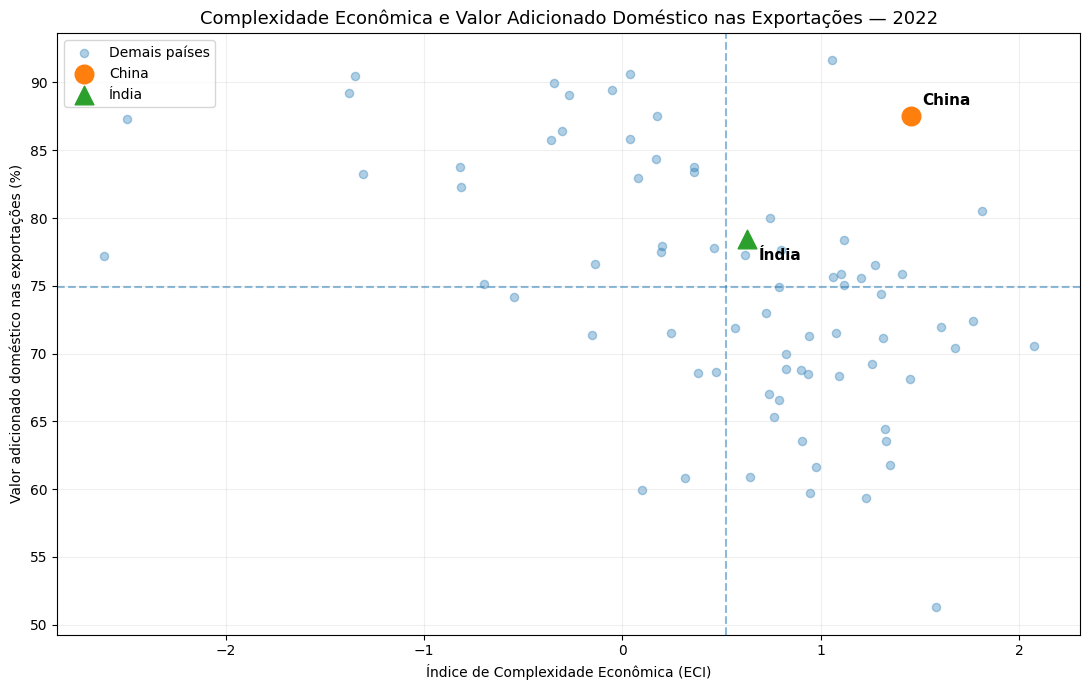


Gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/China_India_contexto_mundial_2022.png


In [55]:
# ======================================================================
# BLOCO 8
# CHINA E ÍNDIA NO CONTEXTO MUNDIAL
# ECI x PARTICIPAÇÃO DO VALOR ADICIONADO DOMÉSTICO
# Ano: 2022
# ======================================================================

ANO_GRAFICO = 2022


# ======================================================================
# 1. TiVA — TODOS OS PAÍSES
# ======================================================================

tiva_mundo = tiva_raw.copy()

# Manter a mesma medida usada no TCC
tiva_mundo = tiva_mundo[
    tiva_mundo["UNIT_MEASURE"] == "PT_EXGR"
].copy()

# Ano escolhido
tiva_mundo = tiva_mundo[
    tiva_mundo["TIME_PERIOD"] == ANO_GRAFICO
].copy()

# Converter DVA
tiva_mundo["OBS_VALUE"] = pd.to_numeric(
    tiva_mundo["OBS_VALUE"],
    errors="coerce"
)

# Média dos setores de cada país
dva_mundo = (
    tiva_mundo
    .groupby(
        "REF_AREA",
        as_index=False
    )["OBS_VALUE"]
    .mean()
    .rename(
        columns={
            "REF_AREA": "country",
            "OBS_VALUE": "DVA_SHARE"
        }
    )
)


# ======================================================================
# 2. ECI — TODOS OS PAÍSES
# ======================================================================

eci_mundo = eci_raw.copy()

eci_mundo = eci_mundo.rename(
    columns={
        "country_iso3_code": "country",
        "eci_sitc": "ECI"
    }
)

eci_mundo["year"] = pd.to_numeric(
    eci_mundo["year"],
    errors="coerce"
)

eci_mundo["ECI"] = pd.to_numeric(
    eci_mundo["ECI"],
    errors="coerce"
)

eci_mundo = eci_mundo[
    eci_mundo["year"] == ANO_GRAFICO
][
    [
        "country",
        "ECI"
    ]
].copy()


# ======================================================================
# 3. JUNTAR DVA + ECI
# ======================================================================

mundo = dva_mundo.merge(
    eci_mundo,
    on="country",
    how="inner"
)

mundo = mundo.dropna(
    subset=[
        "DVA_SHARE",
        "ECI"
    ]
).copy()


print("=" * 80)
print("COMPARAÇÃO INTERNACIONAL")
print("=" * 80)

print(
    "Ano:",
    ANO_GRAFICO
)

print(
    "Países no gráfico:",
    mundo["country"].nunique()
)

display(
    mundo[
        mundo["country"].isin(
            ["CHN", "IND"]
        )
    ]
)


# ======================================================================
# 4. GRÁFICO
# ======================================================================

plt.figure(
    figsize=(11, 7)
)


# ------------------------------------------------------------
# Todos os demais países
# ------------------------------------------------------------

outros = mundo[
    ~mundo["country"].isin(
        ["CHN", "IND"]
    )
]

plt.scatter(
    outros["ECI"],
    outros["DVA_SHARE"],
    alpha=0.35,
    s=35,
    label="Demais países"
)


# ------------------------------------------------------------
# China
# ------------------------------------------------------------

china = mundo[
    mundo["country"] == "CHN"
]

plt.scatter(
    china["ECI"],
    china["DVA_SHARE"],
    s=180,
    marker="o",
    label="China"
)


# ------------------------------------------------------------
# Índia
# ------------------------------------------------------------

india = mundo[
    mundo["country"] == "IND"
]

plt.scatter(
    india["ECI"],
    india["DVA_SHARE"],
    s=180,
    marker="^",
    label="Índia"
)


# ======================================================================
# 5. IDENTIFICAR CHINA E ÍNDIA
# ======================================================================

if len(china) > 0:

    plt.annotate(
        "China",
        (
            china.iloc[0]["ECI"],
            china.iloc[0]["DVA_SHARE"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


if len(india) > 0:

    plt.annotate(
        "Índia",
        (
            india.iloc[0]["ECI"],
            india.iloc[0]["DVA_SHARE"]
        ),
        xytext=(8, -15),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


# ======================================================================
# 6. LINHAS DAS MÉDIAS MUNDIAIS
# ======================================================================

media_eci = mundo["ECI"].mean()
media_dva = mundo["DVA_SHARE"].mean()

plt.axvline(
    media_eci,
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    media_dva,
    linestyle="--",
    alpha=0.5
)


# ======================================================================
# 7. FORMATAÇÃO
# ======================================================================

plt.title(
    f"Complexidade Econômica e Valor Adicionado Doméstico nas Exportações — {ANO_GRAFICO}",
    fontsize=13
)

plt.xlabel(
    "Índice de Complexidade Econômica (ECI)"
)

plt.ylabel(
    "Valor adicionado doméstico nas exportações (%)"
)

plt.legend()

plt.grid(
    alpha=0.20
)

plt.tight_layout()


# ======================================================================
# 8. SALVAR
# ======================================================================

CAMINHO_GRAFICO_MUNDO = (
    f"{PASTA}/China_India_contexto_mundial_{ANO_GRAFICO}.png"
)

plt.savefig(
    CAMINHO_GRAFICO_MUNDO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGráfico salvo em:"
)

print(
    CAMINHO_GRAFICO_MUNDO
)

RANKING MUNDIAL DO ECI
Ano: 2022
Número de países: 145

China e Índia:


,country,ECI,Ranking
6,CHN,1.455,7
45,IND,0.630,46



TOP 20 ECI:


,country,ECI,Ranking
0,TWN,2.073,1
1,JPN,1.814,2
2,HKG,1.768,3
3,KOR,1.679,4
4,CHE,1.608,5
5,SGP,1.582,6
6,CHN,1.455,7
7,CZE,1.449,8
8,DEU,1.409,9
9,HUN,1.347,10


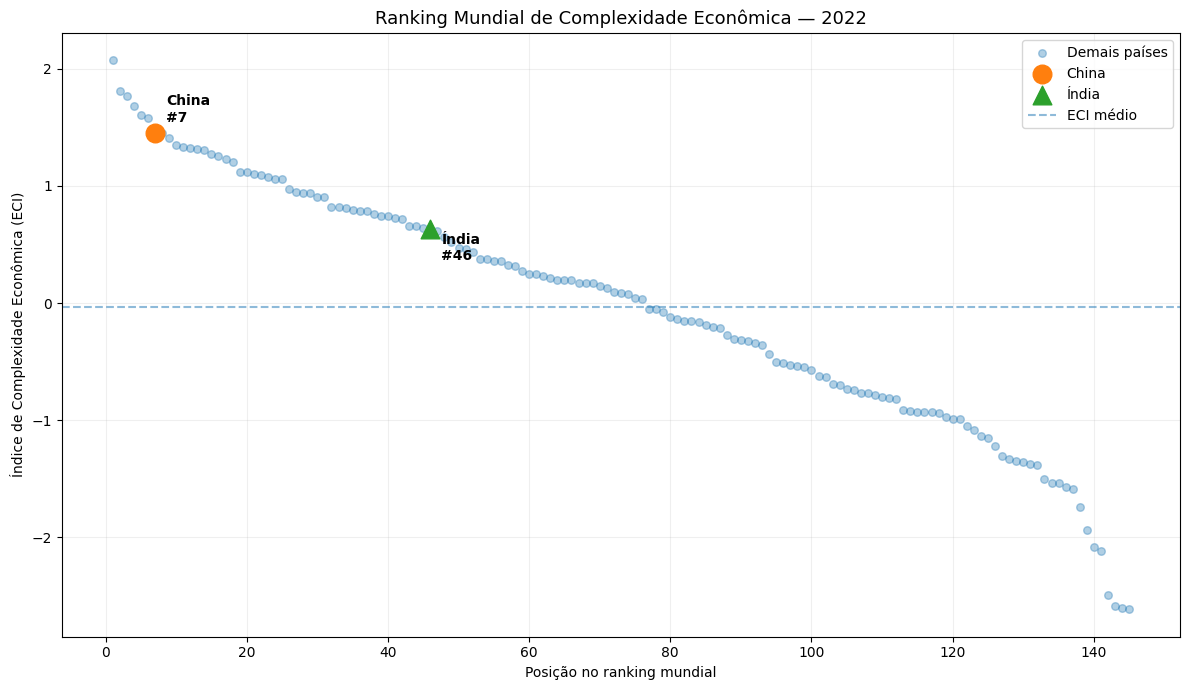


Gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/ranking_mundial_ECI_2022.png


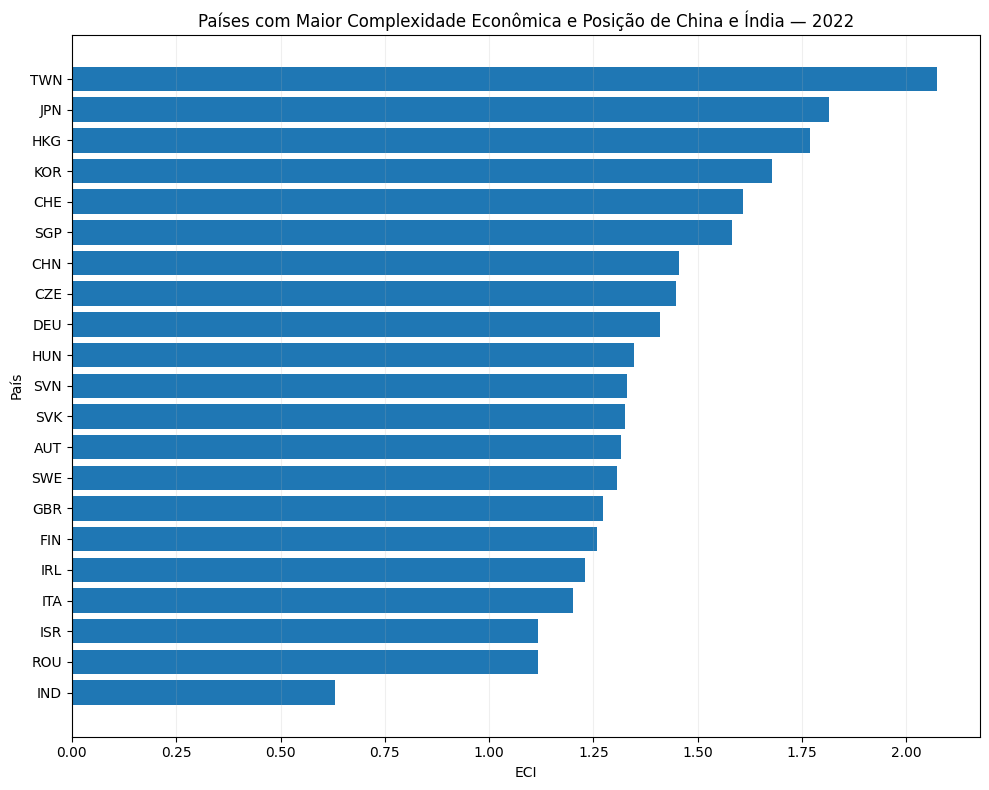


Segundo gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/top20_ECI_China_India_2022.png


In [56]:
# ======================================================================
# BLOCO 9
# RANKING MUNDIAL DO ECI — CHINA E ÍNDIA DESTACADAS
# Ano: 2022
# ======================================================================

ANO_RANKING = 2022


# ======================================================================
# 1. PREPARAR BASE MUNDIAL DO ECI
# ======================================================================

ranking_eci = eci_raw.copy()

ranking_eci = ranking_eci.rename(
    columns={
        "country_iso3_code": "country",
        "eci_sitc": "ECI"
    }
)

ranking_eci["year"] = pd.to_numeric(
    ranking_eci["year"],
    errors="coerce"
)

ranking_eci["ECI"] = pd.to_numeric(
    ranking_eci["ECI"],
    errors="coerce"
)

ranking_eci = ranking_eci[
    ranking_eci["year"] == ANO_RANKING
][
    [
        "country",
        "ECI"
    ]
].dropna().copy()


# ======================================================================
# 2. ORDENAR E CRIAR POSIÇÃO NO RANKING
# ======================================================================

ranking_eci = (
    ranking_eci
    .sort_values(
        "ECI",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_eci["Ranking"] = (
    ranking_eci.index + 1
)


print("=" * 80)
print("RANKING MUNDIAL DO ECI")
print("=" * 80)

print(
    "Ano:",
    ANO_RANKING
)

print(
    "Número de países:",
    len(ranking_eci)
)


# ======================================================================
# 3. MOSTRAR POSIÇÃO DE CHINA E ÍNDIA
# ======================================================================

china_india = ranking_eci[
    ranking_eci["country"].isin(
        ["CHN", "IND"]
    )
].copy()

print("\nChina e Índia:")

display(
    china_india
)


# ======================================================================
# 4. TOP 20 PAÍSES
# ======================================================================

top20 = (
    ranking_eci
    .head(20)
    .copy()
)

print("\nTOP 20 ECI:")

display(
    top20
)


# ======================================================================
# 5. GRÁFICO DO RANKING COMPLETO
# ======================================================================

plt.figure(
    figsize=(12, 7)
)


# ------------------------------------------------------------
# Todos os países
# ------------------------------------------------------------

outros = ranking_eci[
    ~ranking_eci["country"].isin(
        ["CHN", "IND"]
    )
]

plt.scatter(
    outros["Ranking"],
    outros["ECI"],
    alpha=0.35,
    s=30,
    label="Demais países"
)


# ------------------------------------------------------------
# China
# ------------------------------------------------------------

china = ranking_eci[
    ranking_eci["country"] == "CHN"
]

if len(china) > 0:

    plt.scatter(
        china["Ranking"],
        china["ECI"],
        s=180,
        marker="o",
        label="China"
    )

    plt.annotate(
        f"China\n#{int(china.iloc[0]['Ranking'])}",
        (
            china.iloc[0]["Ranking"],
            china.iloc[0]["ECI"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )


# ------------------------------------------------------------
# Índia
# ------------------------------------------------------------

india = ranking_eci[
    ranking_eci["country"] == "IND"
]

if len(india) > 0:

    plt.scatter(
        india["Ranking"],
        india["ECI"],
        s=180,
        marker="^",
        label="Índia"
    )

    plt.annotate(
        f"Índia\n#{int(india.iloc[0]['Ranking'])}",
        (
            india.iloc[0]["Ranking"],
            india.iloc[0]["ECI"]
        ),
        xytext=(8, -22),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )


# ======================================================================
# 6. FORMATAÇÃO
# ======================================================================

plt.axhline(
    ranking_eci["ECI"].mean(),
    linestyle="--",
    alpha=0.5,
    label="ECI médio"
)

plt.title(
    f"Ranking Mundial de Complexidade Econômica — {ANO_RANKING}",
    fontsize=13
)

plt.xlabel(
    "Posição no ranking mundial"
)

plt.ylabel(
    "Índice de Complexidade Econômica (ECI)"
)

plt.grid(
    alpha=0.20
)

plt.legend()

plt.tight_layout()


# ======================================================================
# 7. SALVAR
# ======================================================================

CAMINHO_RANKING_ECI = (
    f"{PASTA}/ranking_mundial_ECI_{ANO_RANKING}.png"
)

plt.savefig(
    CAMINHO_RANKING_ECI,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGráfico salvo em:"
)

print(
    CAMINHO_RANKING_ECI
)


# ======================================================================
# 8. GRÁFICO EXTRA — TOP 20 + CHINA + ÍNDIA
# ======================================================================

paises_destaque = pd.concat(
    [
        top20,
        china_india
    ],
    ignore_index=True
)

paises_destaque = (
    paises_destaque
    .drop_duplicates(
        subset="country"
    )
    .sort_values(
        "ECI",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 8)
)

plt.barh(
    paises_destaque["country"],
    paises_destaque["ECI"]
)

plt.title(
    f"Países com Maior Complexidade Econômica e Posição de China e Índia — {ANO_RANKING}",
    fontsize=12
)

plt.xlabel(
    "ECI"
)

plt.ylabel(
    "País"
)

plt.grid(
    axis="x",
    alpha=0.20
)

plt.tight_layout()


CAMINHO_TOP_ECI = (
    f"{PASTA}/top20_ECI_China_India_{ANO_RANKING}.png"
)

plt.savefig(
    CAMINHO_TOP_ECI,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSegundo gráfico salvo em:"
)

print(
    CAMINHO_TOP_ECI
)

In [57]:
# ======================================================================
# NOMES DOS PAÍSES PARA OS GRÁFICOS INTERNACIONAIS
# ======================================================================

!pip -q install pycountry

import pycountry


# ======================================================================
# 1. FUNÇÃO ISO3 -> NOME DO PAÍS
# ======================================================================

def nome_pais(codigo):

    # nomes que queremos especificamente em português
    nomes_pt = {
        "CHN": "China",
        "IND": "Índia",
        "CHE": "Suíça",
        "DEU": "Alemanha",
        "USA": "Estados Unidos",
        "JPN": "Japão",
        "KOR": "Coreia do Sul",
        "GBR": "Reino Unido",
        "FRA": "França",
        "ITA": "Itália",
        "ESP": "Espanha",
        "PRT": "Portugal",
        "BRA": "Brasil",
        "CAN": "Canadá",
        "AUS": "Austrália",
        "AUT": "Áustria",
        "BEL": "Bélgica",
        "NLD": "Países Baixos",
        "SWE": "Suécia",
        "NOR": "Noruega",
        "DNK": "Dinamarca",
        "FIN": "Finlândia",
        "IRL": "Irlanda",
        "POL": "Polônia",
        "CZE": "Tchéquia",
        "HUN": "Hungria",
        "SVK": "Eslováquia",
        "SVN": "Eslovênia",
        "MEX": "México",
        "ARG": "Argentina",
        "CHL": "Chile",
        "COL": "Colômbia",
        "TUR": "Turquia",
        "RUS": "Rússia",
        "IDN": "Indonésia",
        "MYS": "Malásia",
        "THA": "Tailândia",
        "VNM": "Vietnã",
        "SGP": "Singapura",
        "ISR": "Israel",
        "ZAF": "África do Sul"
    }

    if codigo in nomes_pt:
        return nomes_pt[codigo]

    # Para qualquer país que não esteja no dicionário
    try:

        pais = pycountry.countries.get(
            alpha_3=codigo
        )

        if pais is not None:
            return pais.name

    except:
        pass

    # se não encontrar, mantém o código
    return codigo


# ======================================================================
# 2. APLICAR AO RANKING
# ======================================================================

ranking_eci["País"] = (
    ranking_eci["country"]
    .apply(nome_pais)
)


# ======================================================================
# 3. CONFERIR
# ======================================================================

display(
    ranking_eci[
        [
            "Ranking",
            "country",
            "País",
            "ECI"
        ]
    ].head(30)
)

,Ranking,country,País,ECI
0,1,TWN,"Taiwan, Province of China",2.073
1,2,JPN,Japão,1.814
2,3,HKG,Hong Kong,1.768
3,4,KOR,Coreia do Sul,1.679
4,5,CHE,Suíça,1.608
5,6,SGP,Singapura,1.582
6,7,CHN,China,1.455
7,8,CZE,Tchéquia,1.449
8,9,DEU,Alemanha,1.409
9,10,HUN,Hungria,1.347


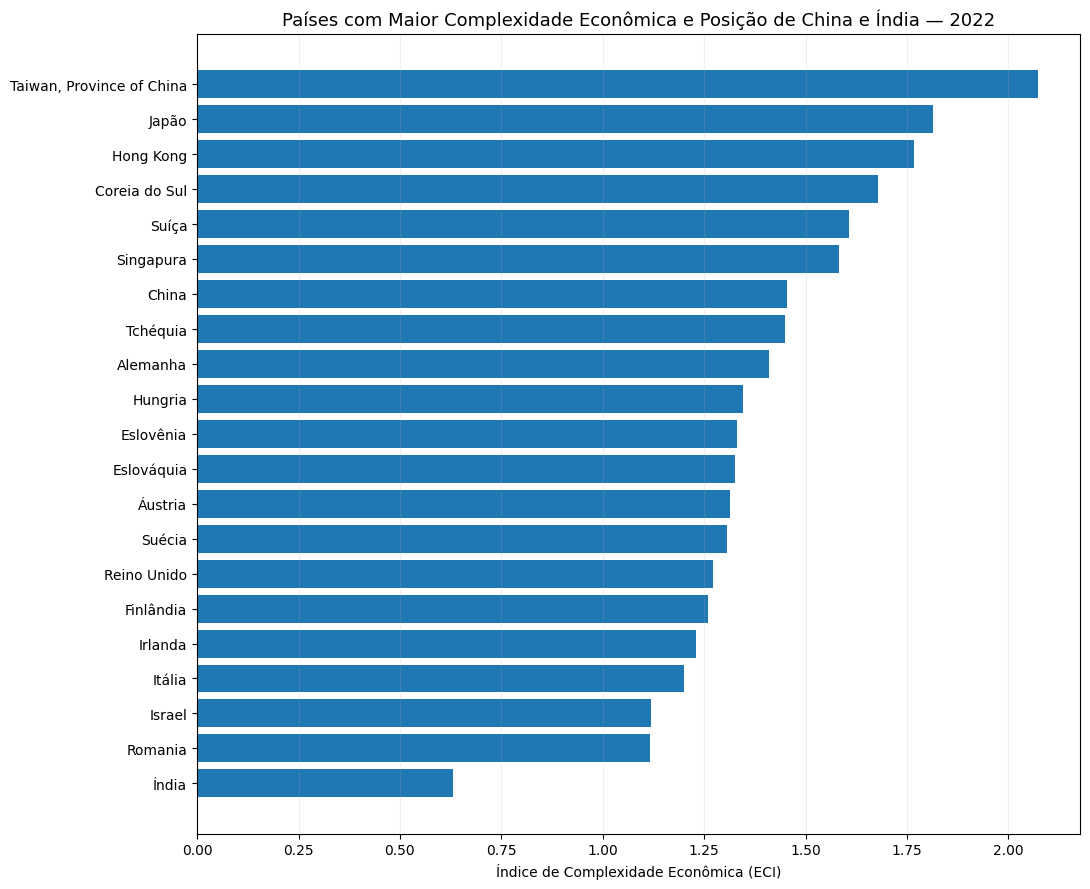

Gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/ranking_ECI_nomes_paises_2022.png


In [58]:
# ======================================================================
# GRÁFICO — TOP 20 + CHINA + ÍNDIA COM NOMES DOS PAÍSES
# ======================================================================

# garantir que a coluna País existe
ranking_eci["País"] = (
    ranking_eci["country"]
    .apply(nome_pais)
)

top20 = (
    ranking_eci
    .head(20)
    .copy()
)

china_india = (
    ranking_eci[
        ranking_eci["country"].isin(
            ["CHN", "IND"]
        )
    ]
    .copy()
)


# juntar top 20 + China + Índia
paises_destaque = pd.concat(
    [
        top20,
        china_india
    ],
    ignore_index=True
)

paises_destaque = (
    paises_destaque
    .drop_duplicates(
        subset="country"
    )
    .sort_values(
        "ECI",
        ascending=True
    )
)


# ======================================================================
# GRÁFICO
# ======================================================================

plt.figure(
    figsize=(11, 9)
)

plt.barh(
    paises_destaque["País"],
    paises_destaque["ECI"]
)

plt.title(
    "Países com Maior Complexidade Econômica "
    "e Posição de China e Índia — 2022",
    fontsize=13
)

plt.xlabel(
    "Índice de Complexidade Econômica (ECI)"
)

plt.ylabel(
    ""
)

plt.grid(
    axis="x",
    alpha=0.20
)

plt.tight_layout()


# ======================================================================
# SALVAR
# ======================================================================

CAMINHO_TOP_ECI_NOMES = (
    f"{PASTA}/ranking_ECI_nomes_paises_2022.png"
)

plt.savefig(
    CAMINHO_TOP_ECI_NOMES,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Gráfico salvo em:"
)

print(
    CAMINHO_TOP_ECI_NOMES
)

TRAJETÓRIA DO ECI — CHINA E ÍNDIA


,País,year,ECI
745,China,1995,0.716
746,China,1996,0.689
747,China,1997,0.689
748,China,1998,0.712
749,China,1999,0.740


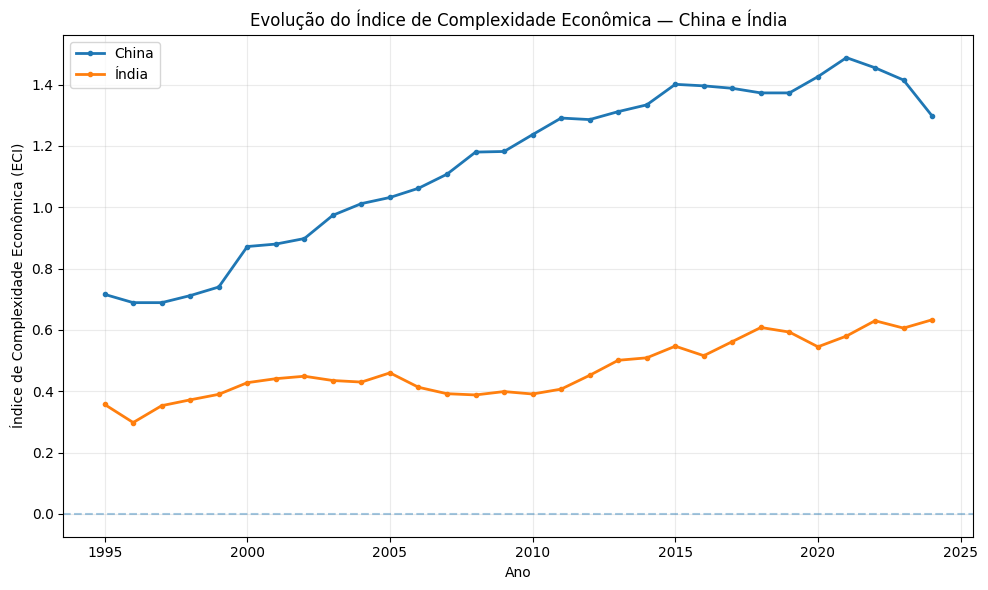


Gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/trajetoria_ECI_China_India.png

P&D x ECI — CONTEXTO MUNDIAL
Ano utilizado: 2022
Países no gráfico: 78

China e Índia:


,País,RD,ECI
12,China,2.4945,1.455


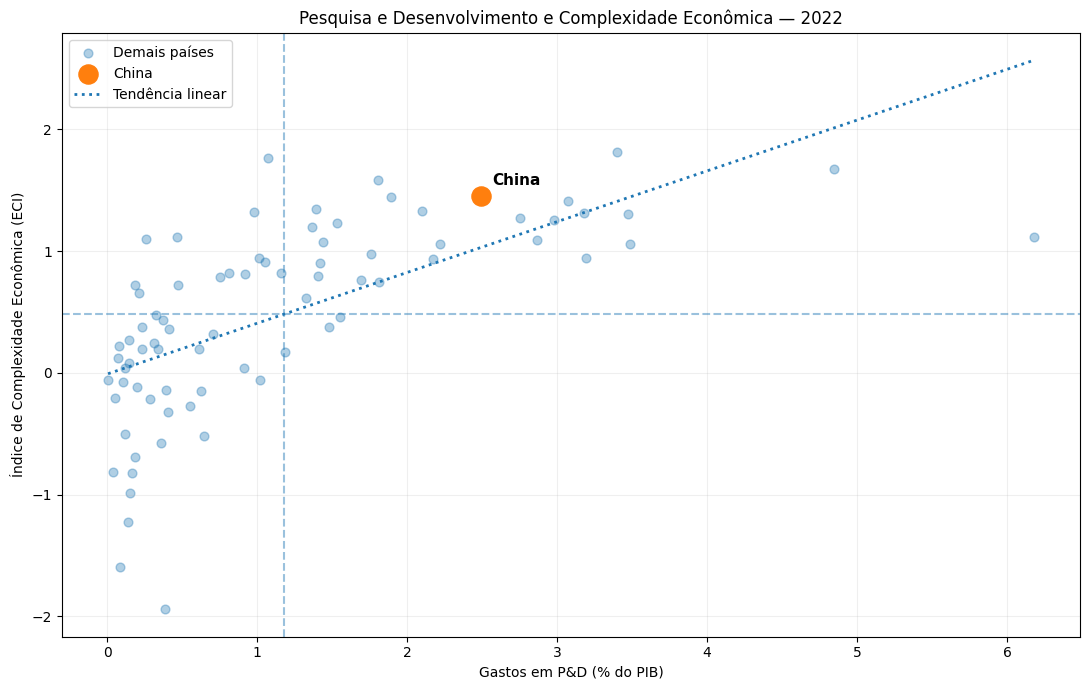


Gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/RD_ECI_mundo_2022.png

CHECK FINAL — BLOCO 10
Trajetória do ECI: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/trajetoria_ECI_China_India.png
P&D x ECI mundial: /content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/RD_ECI_mundo_2022.png
Ano do gráfico internacional: 2022
Número de países: 78

BLOCO 10 CONCLUÍDO


In [59]:
# ======================================================================
# BLOCO 10
# GRÁFICOS INTERNACIONAIS COMPLEMENTARES
# 1. TRAJETÓRIA DO ECI — CHINA x ÍNDIA
# 2. P&D x ECI — TODOS OS PAÍSES, COM CHINA E ÍNDIA DESTACADAS
# ======================================================================


# ======================================================================
# PARTE 1 — TRAJETÓRIA DO ECI DE CHINA E ÍNDIA
# ======================================================================

eci_trajetoria = eci_raw.copy()

eci_trajetoria = eci_trajetoria.rename(
    columns={
        "country_iso3_code": "country",
        "eci_sitc": "ECI"
    }
)

eci_trajetoria["year"] = pd.to_numeric(
    eci_trajetoria["year"],
    errors="coerce"
)

eci_trajetoria["ECI"] = pd.to_numeric(
    eci_trajetoria["ECI"],
    errors="coerce"
)

eci_trajetoria = eci_trajetoria[
    eci_trajetoria["country"].isin(
        ["CHN", "IND"]
    )
].copy()

eci_trajetoria["País"] = (
    eci_trajetoria["country"]
    .map({
        "CHN": "China",
        "IND": "Índia"
    })
)

eci_trajetoria = (
    eci_trajetoria
    .dropna(
        subset=[
            "year",
            "ECI"
        ]
    )
    .sort_values(
        [
            "País",
            "year"
        ]
    )
)


print("=" * 85)
print("TRAJETÓRIA DO ECI — CHINA E ÍNDIA")
print("=" * 85)

display(
    eci_trajetoria[
        [
            "País",
            "year",
            "ECI"
        ]
    ].head()
)


plt.figure(
    figsize=(10, 6)
)

for pais in [
    "China",
    "Índia"
]:

    temp = (
        eci_trajetoria[
            eci_trajetoria["País"] == pais
        ]
        .sort_values("year")
    )

    plt.plot(
        temp["year"],
        temp["ECI"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=pais
    )


plt.axhline(
    0,
    linestyle="--",
    alpha=0.4
)

plt.title(
    "Evolução do Índice de Complexidade Econômica — China e Índia"
)

plt.xlabel(
    "Ano"
)

plt.ylabel(
    "Índice de Complexidade Econômica (ECI)"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


CAMINHO_ECI_TRAJETORIA = (
    f"{PASTA}/trajetoria_ECI_China_India.png"
)

plt.savefig(
    CAMINHO_ECI_TRAJETORIA,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGráfico salvo em:"
)

print(
    CAMINHO_ECI_TRAJETORIA
)


# ======================================================================
# PARTE 2 — P&D x ECI NO MUNDO
# ======================================================================

# Vamos usar o ano de 2022.
# Caso o Banco Mundial não tenha P&D para vários países em 2022,
# o código procura automaticamente o ano mais recente comum.
# ======================================================================


# ----------------------------------------------------------------------
# 2.1 BAIXAR P&D PARA TODOS OS PAÍSES
# ----------------------------------------------------------------------

CODIGO_RD = "GB.XPD.RSDV.GD.ZS"

url_rd_mundo = (
    "https://api.worldbank.org/v2/"
    f"country/all/indicator/{CODIGO_RD}"
)

parametros_rd = {
    "format": "json",
    "date": "1995:2022",
    "per_page": 30000
}

resposta_rd = requests.get(
    url_rd_mundo,
    params=parametros_rd,
    timeout=90
)

resposta_rd.raise_for_status()

conteudo_rd = resposta_rd.json()

if (
    not isinstance(conteudo_rd, list)
    or len(conteudo_rd) < 2
    or conteudo_rd[1] is None
):

    raise ValueError(
        "Banco Mundial não retornou dados mundiais de P&D."
    )


registros_rd = []

for item in conteudo_rd[1]:

    codigo = item.get(
        "countryiso3code"
    )

    valor = item.get(
        "value"
    )

    ano = item.get(
        "date"
    )

    if codigo and valor is not None:

        registros_rd.append({
            "country": codigo,
            "year": int(ano),
            "RD": valor
        })


rd_mundo = pd.DataFrame(
    registros_rd
)

rd_mundo["RD"] = pd.to_numeric(
    rd_mundo["RD"],
    errors="coerce"
)

rd_mundo = rd_mundo.dropna(
    subset=[
        "country",
        "year",
        "RD"
    ]
)


# ----------------------------------------------------------------------
# 2.2 PREPARAR ECI MUNDIAL
# ----------------------------------------------------------------------

eci_mundo_completo = eci_raw.copy()

eci_mundo_completo = eci_mundo_completo.rename(
    columns={
        "country_iso3_code": "country",
        "eci_sitc": "ECI"
    }
)

eci_mundo_completo["year"] = pd.to_numeric(
    eci_mundo_completo["year"],
    errors="coerce"
)

eci_mundo_completo["ECI"] = pd.to_numeric(
    eci_mundo_completo["ECI"],
    errors="coerce"
)

eci_mundo_completo = eci_mundo_completo.dropna(
    subset=[
        "country",
        "year",
        "ECI"
    ]
)


# ----------------------------------------------------------------------
# 2.3 DESCOBRIR O ANO MAIS RECENTE COM BOA COBERTURA
# ----------------------------------------------------------------------

anos_possiveis = sorted(
    set(
        rd_mundo["year"].unique()
    ).intersection(
        set(
            eci_mundo_completo["year"].unique()
        )
    ),
    reverse=True
)

ano_grafico = None
base_mundo = None


for ano in anos_possiveis:

    temp_rd = rd_mundo[
        rd_mundo["year"] == ano
    ][
        [
            "country",
            "RD"
        ]
    ]

    temp_eci = eci_mundo_completo[
        eci_mundo_completo["year"] == ano
    ][
        [
            "country",
            "ECI"
        ]
    ]

    temp = temp_rd.merge(
        temp_eci,
        on="country",
        how="inner"
    )

    temp = temp.dropna(
        subset=[
            "RD",
            "ECI"
        ]
    )

    # Queremos uma quantidade razoável de países
    if len(temp) >= 40:

        ano_grafico = ano
        base_mundo = temp.copy()
        break


if ano_grafico is None:

    raise ValueError(
        "Não foi encontrado ano com cobertura suficiente para P&D e ECI."
    )


print("\n" + "=" * 85)
print("P&D x ECI — CONTEXTO MUNDIAL")
print("=" * 85)

print(
    "Ano utilizado:",
    ano_grafico
)

print(
    "Países no gráfico:",
    len(base_mundo)
)


# ----------------------------------------------------------------------
# 2.4 ADICIONAR NOMES DOS PAÍSES
# ----------------------------------------------------------------------

base_mundo["País"] = (
    base_mundo["country"]
    .apply(nome_pais)
)


# ----------------------------------------------------------------------
# 2.5 MOSTRAR CHINA E ÍNDIA
# ----------------------------------------------------------------------

china_india_rd_eci = base_mundo[
    base_mundo["country"].isin(
        ["CHN", "IND"]
    )
].copy()


print("\nChina e Índia:")

display(
    china_india_rd_eci[
        [
            "País",
            "RD",
            "ECI"
        ]
    ]
)


# ======================================================================
# 2.6 GRÁFICO P&D x ECI
# ======================================================================

plt.figure(
    figsize=(11, 7)
)


# Demais países
outros = base_mundo[
    ~base_mundo["country"].isin(
        ["CHN", "IND"]
    )
]

plt.scatter(
    outros["RD"],
    outros["ECI"],
    alpha=0.35,
    s=40,
    label="Demais países"
)


# China
china = base_mundo[
    base_mundo["country"] == "CHN"
]

if len(china) > 0:

    plt.scatter(
        china["RD"],
        china["ECI"],
        s=190,
        marker="o",
        label="China"
    )

    plt.annotate(
        "China",
        (
            china.iloc[0]["RD"],
            china.iloc[0]["ECI"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


# Índia
india = base_mundo[
    base_mundo["country"] == "IND"
]

if len(india) > 0:

    plt.scatter(
        india["RD"],
        india["ECI"],
        s=190,
        marker="^",
        label="Índia"
    )

    plt.annotate(
        "Índia",
        (
            india.iloc[0]["RD"],
            india.iloc[0]["ECI"]
        ),
        xytext=(8, -16),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


# ======================================================================
# 2.7 MÉDIAS MUNDIAIS
# ======================================================================

media_rd = (
    base_mundo["RD"]
    .mean()
)

media_eci = (
    base_mundo["ECI"]
    .mean()
)

plt.axvline(
    media_rd,
    linestyle="--",
    alpha=0.45
)

plt.axhline(
    media_eci,
    linestyle="--",
    alpha=0.45
)


# ======================================================================
# 2.8 LINHA DE TENDÊNCIA
# ======================================================================

coef_tendencia = np.polyfit(
    base_mundo["RD"],
    base_mundo["ECI"],
    1
)

x_tendencia = np.linspace(
    base_mundo["RD"].min(),
    base_mundo["RD"].max(),
    100
)

y_tendencia = np.polyval(
    coef_tendencia,
    x_tendencia
)

plt.plot(
    x_tendencia,
    y_tendencia,
    linestyle=":",
    linewidth=2,
    label="Tendência linear"
)


# ======================================================================
# 2.9 FORMATAÇÃO
# ======================================================================

plt.title(
    f"Pesquisa e Desenvolvimento e Complexidade Econômica — {ano_grafico}"
)

plt.xlabel(
    "Gastos em P&D (% do PIB)"
)

plt.ylabel(
    "Índice de Complexidade Econômica (ECI)"
)

plt.legend()

plt.grid(
    alpha=0.20
)

plt.tight_layout()


CAMINHO_RD_ECI = (
    f"{PASTA}/RD_ECI_mundo_{ano_grafico}.png"
)

plt.savefig(
    CAMINHO_RD_ECI,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGráfico salvo em:"
)

print(
    CAMINHO_RD_ECI
)


# ======================================================================
# 3. CHECK FINAL
# ======================================================================

print("\n" + "=" * 85)
print("CHECK FINAL — BLOCO 10")
print("=" * 85)

print(
    "Trajetória do ECI:",
    CAMINHO_ECI_TRAJETORIA
)

print(
    "P&D x ECI mundial:",
    CAMINHO_RD_ECI
)

print(
    "Ano do gráfico internacional:",
    ano_grafico
)

print(
    "Número de países:",
    len(base_mundo)
)

print("\nBLOCO 10 CONCLUÍDO")

In [60]:
# ======================================================================
# 2.3 DESCOBRIR O ANO MAIS RECENTE COM:
#
# - boa cobertura internacional
# - China presente
# - Índia presente
# - P&D e ECI disponíveis para ambas
# ======================================================================

anos_possiveis = sorted(
    set(
        rd_mundo["year"].unique()
    ).intersection(
        set(
            eci_mundo_completo["year"].unique()
        )
    ),
    reverse=True
)

ano_grafico = None
base_mundo = None


for ano in anos_possiveis:

    # P&D naquele ano
    temp_rd = rd_mundo[
        rd_mundo["year"] == ano
    ][
        [
            "country",
            "RD"
        ]
    ].copy()


    # ECI naquele ano
    temp_eci = eci_mundo_completo[
        eci_mundo_completo["year"] == ano
    ][
        [
            "country",
            "ECI"
        ]
    ].copy()


    # Juntar P&D + ECI
    temp = temp_rd.merge(
        temp_eci,
        on="country",
        how="inner"
    )


    temp = temp.dropna(
        subset=[
            "RD",
            "ECI"
        ]
    )


    # --------------------------------------------------------------
    # GARANTIR CHINA E ÍNDIA
    # --------------------------------------------------------------

    paises_presentes = set(
        temp["country"].unique()
    )

    tem_china = (
        "CHN" in paises_presentes
    )

    tem_india = (
        "IND" in paises_presentes
    )


    # --------------------------------------------------------------
    # ESCOLHER SOMENTE SE:
    # 1. houver pelo menos 40 países
    # 2. China estiver presente
    # 3. Índia estiver presente
    # --------------------------------------------------------------

    if (
        len(temp) >= 40
        and tem_china
        and tem_india
    ):

        ano_grafico = ano
        base_mundo = temp.copy()

        break


# ======================================================================
# GARANTIA
# ======================================================================

if ano_grafico is None:

    raise ValueError(
        "Não foi encontrado um ano com boa cobertura "
        "internacional e dados simultâneos de P&D e ECI "
        "para China e Índia."
    )


# ======================================================================
# CONFERÊNCIA
# ======================================================================

print("=" * 85)
print("ANO ESCOLHIDO PARA P&D x ECI")
print("=" * 85)

print(
    "Ano:",
    ano_grafico
)

print(
    "Número de países:",
    len(base_mundo)
)


print("\nChina:")

display(
    base_mundo[
        base_mundo["country"] == "CHN"
    ]
)


print("\nÍndia:")

display(
    base_mundo[
        base_mundo["country"] == "IND"
    ]
)

ANO ESCOLHIDO PARA P&D x ECI
Ano: 2020
Número de países: 82

China:


,country,RD,ECI
12,CHN,2.35712,1.426



Índia:


,country,RD,ECI
31,IND,0.64558,0.545


ÍNDIA — P&D E COMPLEXIDADE ECONÔMICA
Ano utilizado: 2020
Países comparados: 82

Dados da Índia:


,País,RD,ECI
31,Índia,0.64558,0.545


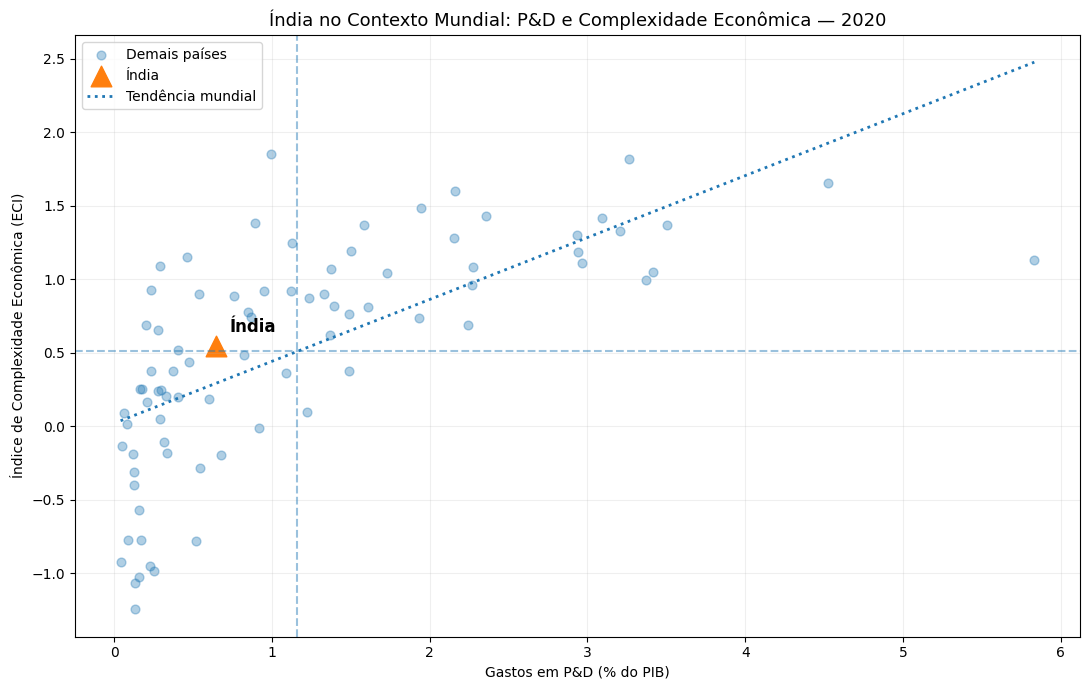


Gráfico salvo em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/India_RD_ECI_contexto_mundial_2020.png


In [61]:
# ======================================================================
# GRÁFICO INTERNACIONAL DA ÍNDIA
# P&D x COMPLEXIDADE ECONÔMICA
# Usa o ano mais recente com dados disponíveis para a Índia
# ======================================================================


# ======================================================================
# 1. ENCONTRAR O ANO MAIS RECENTE COM DADOS DA ÍNDIA
# ======================================================================

anos_india = sorted(
    set(rd_mundo["year"].unique()).intersection(
        set(eci_mundo_completo["year"].unique())
    ),
    reverse=True
)

ano_india = None
mundo_india = None


for ano in anos_india:

    # P&D mundial naquele ano
    temp_rd = rd_mundo[
        rd_mundo["year"] == ano
    ][
        ["country", "RD"]
    ].copy()

    # ECI mundial naquele ano
    temp_eci = eci_mundo_completo[
        eci_mundo_completo["year"] == ano
    ][
        ["country", "ECI"]
    ].copy()

    # juntar P&D + ECI
    temp = temp_rd.merge(
        temp_eci,
        on="country",
        how="inner"
    )

    temp = temp.dropna(
        subset=["RD", "ECI"]
    )

    # Índia precisa existir
    tem_india = (
        "IND" in temp["country"].unique()
    )

    # também queremos boa comparação internacional
    if tem_india and len(temp) >= 30:

        ano_india = ano
        mundo_india = temp.copy()

        break


if ano_india is None:

    raise ValueError(
        "Não encontrei um ano com dados simultâneos "
        "de P&D e ECI para a Índia."
    )


# ======================================================================
# 2. ADICIONAR NOMES DOS PAÍSES
# ======================================================================

mundo_india["País"] = (
    mundo_india["country"]
    .apply(nome_pais)
)


# ======================================================================
# 3. DADOS DA ÍNDIA
# ======================================================================

india = mundo_india[
    mundo_india["country"] == "IND"
].copy()


print("=" * 80)
print("ÍNDIA — P&D E COMPLEXIDADE ECONÔMICA")
print("=" * 80)

print(
    "Ano utilizado:",
    ano_india
)

print(
    "Países comparados:",
    len(mundo_india)
)

print("\nDados da Índia:")

display(
    india[
        [
            "País",
            "RD",
            "ECI"
        ]
    ]
)


# ======================================================================
# 4. GRÁFICO
# ======================================================================

plt.figure(
    figsize=(11, 7)
)


# ----------------------------------------------------------------------
# Demais países
# ----------------------------------------------------------------------

outros = mundo_india[
    mundo_india["country"] != "IND"
]

plt.scatter(
    outros["RD"],
    outros["ECI"],
    alpha=0.35,
    s=40,
    label="Demais países"
)


# ----------------------------------------------------------------------
# Índia destacada
# ----------------------------------------------------------------------

plt.scatter(
    india["RD"],
    india["ECI"],
    s=220,
    marker="^",
    label="Índia"
)


# Nome da Índia no gráfico
plt.annotate(
    "Índia",
    (
        india.iloc[0]["RD"],
        india.iloc[0]["ECI"]
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=12,
    fontweight="bold"
)


# ======================================================================
# 5. MÉDIAS MUNDIAIS
# ======================================================================

media_rd = (
    mundo_india["RD"].mean()
)

media_eci = (
    mundo_india["ECI"].mean()
)


plt.axvline(
    media_rd,
    linestyle="--",
    alpha=0.45
)

plt.axhline(
    media_eci,
    linestyle="--",
    alpha=0.45
)


# ======================================================================
# 6. LINHA DE TENDÊNCIA MUNDIAL
# ======================================================================

coef = np.polyfit(
    mundo_india["RD"],
    mundo_india["ECI"],
    1
)

x_linha = np.linspace(
    mundo_india["RD"].min(),
    mundo_india["RD"].max(),
    100
)

y_linha = np.polyval(
    coef,
    x_linha
)

plt.plot(
    x_linha,
    y_linha,
    linestyle=":",
    linewidth=2,
    label="Tendência mundial"
)


# ======================================================================
# 7. FORMATAÇÃO
# ======================================================================

plt.title(
    f"Índia no Contexto Mundial: "
    f"P&D e Complexidade Econômica — {ano_india}",
    fontsize=13
)

plt.xlabel(
    "Gastos em P&D (% do PIB)"
)

plt.ylabel(
    "Índice de Complexidade Econômica (ECI)"
)

plt.legend()

plt.grid(
    alpha=0.20
)

plt.tight_layout()


# ======================================================================
# 8. SALVAR
# ======================================================================

CAMINHO_INDIA_MUNDO = (
    f"{PASTA}/India_RD_ECI_contexto_mundial_{ano_india}.png"
)

plt.savefig(
    CAMINHO_INDIA_MUNDO,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nGráfico salvo em:"
)

print(
    CAMINHO_INDIA_MUNDO
)

In [62]:
print(tiva_raw["COUNTERPART_AREA"].nunique())

print(
    tiva_raw["COUNTERPART_AREA"]
    .value_counts()
    .head(30)
)

1
COUNTERPART_AREA
W    216776
Name: count, dtype: int64


In [63]:
# ============================================================
# TESTE API OECD — TiVA bilateral
# ============================================================

import requests
import pandas as pd
from io import StringIO

url = (
    "https://sdmx.oecd.org/sti-public/rest/data/"
    "OECD.STI.PIE,DSD_TIVA_IMGRVA@DF_IMGRVA,1.1/"
    ".CHN..IND._T..A"
)

params = {
    "startPeriod": "2022",
    "endPeriod": "2022",
    "dimensionAtObservation": "AllDimensions"
}

headers = {
    "Accept": "text/csv"
}

r = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=60
)

print("Status:", r.status_code)
print(r.text[:1000])

Status: 200
DATAFLOW,MEASURE,IMPORTING_AREA,VALUE_ADDED_SOURCE_AREA,EXPORTING_AREA,EXPORTING_ACTIVITY,UNIT_MEASURE,FREQ,TIME_PERIOD,OBS_VALUE,UNIT_MULT
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,STP,IND,_T,USD,A,2022,0.009,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,EST,IND,_T,USD,A,2022,2.46,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,PRT,IND,_T,USD,A,2022,6.206,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,EGY,IND,_T,USD,A,2022,42.214,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,FRA,IND,_T,USD,A,2022,108.339,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,WXD,IND,_T,USD,A,2022,1469.371,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,ROU,IND,_T,USD,A,2022,13.698,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,ARE,IND,_T,USD,A,2022,491.013,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,SGP,IND,_T,USD,A,2022,327.029,6
OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,EU15,IND,_T,USD,A,

In [64]:
# ============================================================
# INSPECIONAR A BASE BILATERAL QUE ACABAMOS DE OBTER
# ============================================================

from io import StringIO
import pandas as pd

bilateral_teste = pd.read_csv(
    StringIO(r.text)
)

print("=" * 80)
print("ESTRUTURA DA BASE BILATERAL")
print("=" * 80)

print("\nShape:")
print(bilateral_teste.shape)

print("\nColunas:")
print(bilateral_teste.columns.tolist())


# ============================================================
# VALORES ÚNICOS DAS DIMENSÕES IMPORTANTES
# ============================================================

for coluna in [
    "MEASURE",
    "IMPORTING_AREA",
    "VALUE_ADDED_SOURCE_AREA",
    "EXPORTING_AREA",
    "EXPORTING_ACTIVITY",
    "UNIT_MEASURE",
    "TIME_PERIOD"
]:

    if coluna in bilateral_teste.columns:

        print("\n" + "-" * 80)
        print(coluna)
        print("-" * 80)

        print(
            bilateral_teste[coluna]
            .value_counts()
            .head(20)
        )


# ============================================================
# PRIMEIRAS OBSERVAÇÕES
# ============================================================

print("\n" + "=" * 80)
print("PRIMEIRAS OBSERVAÇÕES")
print("=" * 80)

display(
    bilateral_teste.head(20)
)

ESTRUTURA DA BASE BILATERAL

Shape:
(100, 11)

Colunas:
['DATAFLOW', 'MEASURE', 'IMPORTING_AREA', 'VALUE_ADDED_SOURCE_AREA', 'EXPORTING_AREA', 'EXPORTING_ACTIVITY', 'UNIT_MEASURE', 'FREQ', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MULT']

--------------------------------------------------------------------------------
MEASURE
--------------------------------------------------------------------------------
MEASURE
IMGRVA    100
Name: count, dtype: int64

--------------------------------------------------------------------------------
IMPORTING_AREA
--------------------------------------------------------------------------------
IMPORTING_AREA
CHN    100
Name: count, dtype: int64

--------------------------------------------------------------------------------
VALUE_ADDED_SOURCE_AREA
--------------------------------------------------------------------------------
VALUE_ADDED_SOURCE_AREA
STP      1
EST      1
PRT      1
EGY      1
FRA      1
WXD      1
ROU      1
ARE      1
SGP      1
EU15     1


,DATAFLOW,MEASURE,IMPORTING_AREA,VALUE_ADDED_SOURCE_AREA,EXPORTING_AREA,EXPORTING_ACTIVITY,UNIT_MEASURE,FREQ,TIME_PERIOD,OBS_VALUE,UNIT_MULT
0,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,STP,IND,_T,USD,A,2022,0.009,6
1,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,EST,IND,_T,USD,A,2022,2.460,6
2,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,PRT,IND,_T,USD,A,2022,6.206,6
3,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,EGY,IND,_T,USD,A,2022,42.214,6
4,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,FRA,IND,_T,USD,A,2022,108.339,6
5,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,WXD,IND,_T,USD,A,2022,1469.371,6
6,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,ROU,IND,_T,USD,A,2022,13.698,6
7,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,ARE,IND,_T,USD,A,2022,491.013,6
8,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,SGP,IND,_T,USD,A,2022,327.029,6
9,OECD.STI.PIE:DSD_TIVA_IMGRVA@DF_IMGRVA(1.1),IMGRVA,CHN,EU15,IND,_T,USD,A,2022,971.299,6


In [65]:
# ============================================================
# CHECK NUMÉRICO — IMPORTÂNCIA RELATIVA DE CHINA E ÍNDIA
# ============================================================

resultado_check = []

for ano in [2000, 2010, 2022]:

    temp = fluxos_top_mundo[
        fluxos_top_mundo["TIME_PERIOD"] == ano
    ].copy()

    # construir a importância exatamente como no gráfico:
    # soma dos fluxos de entrada + saída
    paises = set(
        temp["EXPORTING_AREA"]
    ).union(
        set(temp["IMPORTING_AREA"])
    )

    importancia = {}

    for pais in paises:

        entrada = temp.loc[
            temp["IMPORTING_AREA"] == pais,
            "Peso"
        ].sum()

        saida = temp.loc[
            temp["EXPORTING_AREA"] == pais,
            "Peso"
        ].sum()

        importancia[pais] = entrada + saida

    max_importancia = max(
        importancia.values()
    )

    for pais in ["CHN", "IND"]:

        valor = importancia.get(
            pais,
            0
        )

        proporcao = (
            valor / max_importancia
            if max_importancia > 0
            else np.nan
        )

        resultado_check.append({
            "Ano": ano,
            "País": "China" if pais == "CHN" else "Índia",
            "Importância": valor,
            "Importância relativa ao maior nó": proporcao
        })


check_rede = pd.DataFrame(
    resultado_check
)

check_rede["Importância"] = (
    check_rede["Importância"]
    .round(2)
)

check_rede["Importância relativa ao maior nó"] = (
    check_rede["Importância relativa ao maior nó"]
    .round(3)
)

display(
    check_rede
)

,Ano,País,Importância,Importância relativa ao maior nó
0,2000,China,196545.72,1.000
1,2000,Índia,50245.24,0.256
2,2010,China,1080304.31,1.000
3,2010,Índia,323079.43,0.299
4,2022,China,2543153.38,1.000
5,2022,Índia,675989.15,0.266


| Ano  |        China |      Índia | Índia em relação à China |
| ---- | -----------: | ---------: | -----------------------: |
| 2000 |   196.545,72 |  50.245,24 |                **25,6%** |
| 2010 | 1.080.304,31 | 323.079,43 |                **29,9%** |
| 2022 | 2.543.153,38 | 675.989,15 |                **26,6%** |


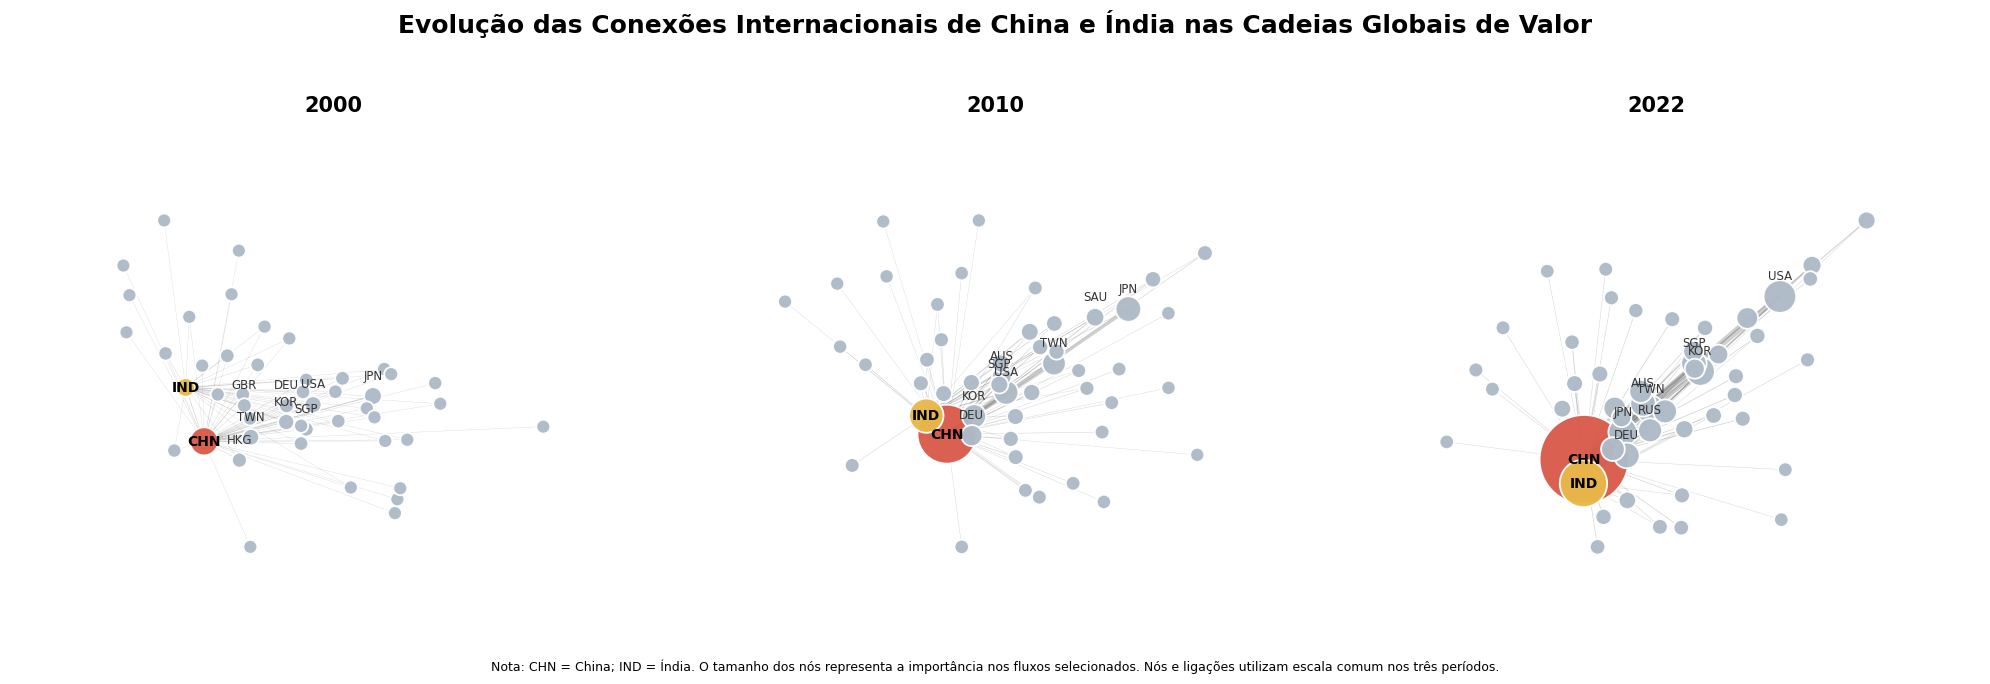


Figura final salva em:
/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca/rede_CGV_CHN_IND_FINAL.png


In [66]:
# ======================================================================
# GRÁFICO FINAL — VERSÃO VISUAL ARRUMADA
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


ANOS_REDE = [2000, 2010, 2022]
TOP_LABELS = 10


# ======================================================================
# 1. IMPORTÂNCIA POR ANO
# ======================================================================

importancia_por_ano = {}

for ano in ANOS_REDE:

    temp = fluxos_top_mundo[
        fluxos_top_mundo["TIME_PERIOD"] == ano
    ].copy()

    paises = set(temp["EXPORTING_AREA"]).union(
        set(temp["IMPORTING_AREA"])
    )

    importancia = {}

    for pais in paises:

        entrada = temp.loc[
            temp["IMPORTING_AREA"] == pais,
            "Peso"
        ].sum()

        saida = temp.loc[
            temp["EXPORTING_AREA"] == pais,
            "Peso"
        ].sum()

        importancia[pais] = entrada + saida

    importancia_por_ano[ano] = importancia


# ======================================================================
# 2. ESCALA COMUM ENTRE OS TRÊS ANOS
# ======================================================================

MAX_GLOBAL = max(
    valor
    for ano in ANOS_REDE
    for valor in importancia_por_ano[ano].values()
)

MAX_PESO_GLOBAL = fluxos_top_mundo.loc[
    fluxos_top_mundo["TIME_PERIOD"].isin(ANOS_REDE),
    "Peso"
].max()


# ======================================================================
# 3. FUNÇÃO DO GRÁFICO
# ======================================================================

def desenhar_rede_final(ax, ano):

    temp = fluxos_top_mundo[
        fluxos_top_mundo["TIME_PERIOD"] == ano
    ].copy()

    # --------------------------------------------------------------
    # Criar grafo
    # --------------------------------------------------------------

    G = nx.DiGraph()

    for _, linha in temp.iterrows():

        G.add_edge(
            linha["EXPORTING_AREA"],
            linha["IMPORTING_AREA"],
            weight=linha["Peso"]
        )


    importancia = importancia_por_ano[ano]


    # --------------------------------------------------------------
    # Layout
    # --------------------------------------------------------------

    pos = nx.spring_layout(
        G,
        weight="weight",
        seed=25,
        k=1.8,
        iterations=400
    )


    # --------------------------------------------------------------
    # Tamanho dos nós
    # MESMA escala nos três anos
    # --------------------------------------------------------------

    tamanhos = []

    for node in G.nodes:

        proporcao = (
            importancia[node] / MAX_GLOBAL
        )

        tamanho = (
            100
            + 4000 * proporcao
        )

        tamanhos.append(tamanho)


    # --------------------------------------------------------------
    # Cores
    # --------------------------------------------------------------

    cores = []

    for node in G.nodes:

        if node == "CHN":
            cores.append("#D95C4B")

        elif node == "IND":
            cores.append("#E8B84A")

        else:
            cores.append("#AEBBC8")


    # --------------------------------------------------------------
    # Espessura das ligações
    # MESMA escala nos três anos
    # --------------------------------------------------------------

    larguras = []

    for u, v in G.edges:

        peso = G[u][v]["weight"]

        largura = (
            0.20
            + 3.2 * peso / MAX_PESO_GLOBAL
        )

        larguras.append(largura)


    # --------------------------------------------------------------
    # Ligações — um pouco mais visíveis
    # --------------------------------------------------------------

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=larguras,
        edge_color="#777777",
        alpha=0.35,
        arrows=False
    )


    # --------------------------------------------------------------
    # Nós
    # --------------------------------------------------------------

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=tamanhos,
        node_color=cores,
        edgecolors="white",
        linewidths=1.3,
        alpha=0.97
    )


    # ==================================================================
    # 4. SIGLAS
    # ==================================================================

    ranking = sorted(
        importancia,
        key=importancia.get,
        reverse=True
    )

    # só 10 principais para não poluir
    principais = ranking[:TOP_LABELS]


    # garantir CHN e IND
    for pais in ["CHN", "IND"]:

        if pais in G.nodes and pais not in principais:
            principais.append(pais)


    for node in principais:

        x, y = pos[node]


        # ----------------------------------------------------------
        # China e Índia DENTRO dos círculos
        # ----------------------------------------------------------

        if node in ["CHN", "IND"]:

            ax.text(
                x,
                y,
                node,
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
                color="black",
                zorder=10
            )


        # ----------------------------------------------------------
        # Outros países FORA dos círculos
        # ----------------------------------------------------------

        else:

            ax.annotate(
                node,
                xy=(x, y),
                xytext=(0, 10),
                textcoords="offset points",
                fontsize=8.5,
                ha="center",
                va="bottom",
                color="#333333",
                zorder=10
            )


    # --------------------------------------------------------------
    # Ano
    # --------------------------------------------------------------

    ax.set_title(
        str(ano),
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.margins(0.20)

    ax.axis("off")


# ======================================================================
# 5. GERAR FIGURA
# ======================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)


for ax, ano in zip(
    axes,
    ANOS_REDE
):

    desenhar_rede_final(
        ax,
        ano
    )


# ======================================================================
# 6. TÍTULO
# ======================================================================

fig.suptitle(
    "Evolução das Conexões Internacionais de China e Índia "
    "nas Cadeias Globais de Valor",
    fontsize=18,
    fontweight="bold",
    y=0.97
)


# ======================================================================
# 7. NOTA
# ======================================================================

fig.text(
    0.5,
    0.025,
    "Nota: CHN = China; IND = Índia. "
    "O tamanho dos nós representa a importância nos fluxos selecionados. "
    "Nós e ligações utilizam escala comum nos três períodos.",
    ha="center",
    fontsize=9
)


plt.tight_layout(
    rect=[
        0,
        0.055,
        1,
        0.93
    ]
)


# ======================================================================
# 8. SALVAR
# ======================================================================

CAMINHO_REDE_FINAL = (
    f"{PASTA}/rede_CGV_CHN_IND_FINAL.png"
)


plt.savefig(
    CAMINHO_REDE_FINAL,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("\nFigura final salva em:")
print(CAMINHO_REDE_FINAL)

In [69]:
# ============================================================
# DESCOBRIR OS NOMES DAS BASES E MODELOS NO COLAB
# ============================================================

print("=== DATAFRAMES ===")

for nome, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(
            nome,
            "->",
            obj.shape,
            "->",
            obj.columns.tolist()
        )


print("\n=== MODELOS / RESULTADOS ===")

for nome, obj in list(globals().items()):

    tipo = str(type(obj)).lower()

    if any(
        palavra in tipo
        for palavra in [
            "regression",
            "results",
            "panel",
            "ols"
        ]
    ):
        print(
            nome,
            "->",
            type(obj)
        )

=== DATAFRAMES ===
tiva_raw -> (216776, 10) -> ['DATAFLOW', 'MEASURE', 'REF_AREA', 'ACTIVITY', 'COUNTERPART_AREA', 'UNIT_MEASURE', 'FREQ', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MULT']
tiva -> (4424, 4) -> ['country', 'year', 'sector', 'DVA_SHARE']
pwt_raw -> (13690, 51) -> ['countrycode', 'country', 'currency_unit', 'year', 'rgdpe', 'rgdpo', 'pop', 'emp', 'avh', 'hc', 'ccon', 'cda', 'cgdpe', 'cgdpo', 'cn', 'ck', 'ctfp', 'cwtfp', 'rgdpna', 'rconna', 'rdana', 'rnna', 'rkna', 'rtfpna', 'rwtfpna', 'labsh', 'irr', 'delta', 'xr', 'pl_con', 'pl_da', 'pl_gdpo', 'i_cig', 'i_xm', 'i_xr', 'i_outlier', 'i_irr', 'cor_exp', 'csh_c', 'csh_i', 'csh_g', 'csh_x', 'csh_m', 'csh_r', 'pl_c', 'pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_n', 'pl_k']
pwt -> (56, 7) -> ['country', 'year', 'PTF', 'HumanCapital', 'GDP', 'Population', 'Employment']
temp -> (80, 4) -> ['TIME_PERIOD', 'EXPORTING_AREA', 'IMPORTING_AREA', 'Peso']
wb -> (56, 4) -> ['country', 'year', 'PIBpc', 'RD']
eci_raw -> (4319, 11) -> ['country_id', 'country_